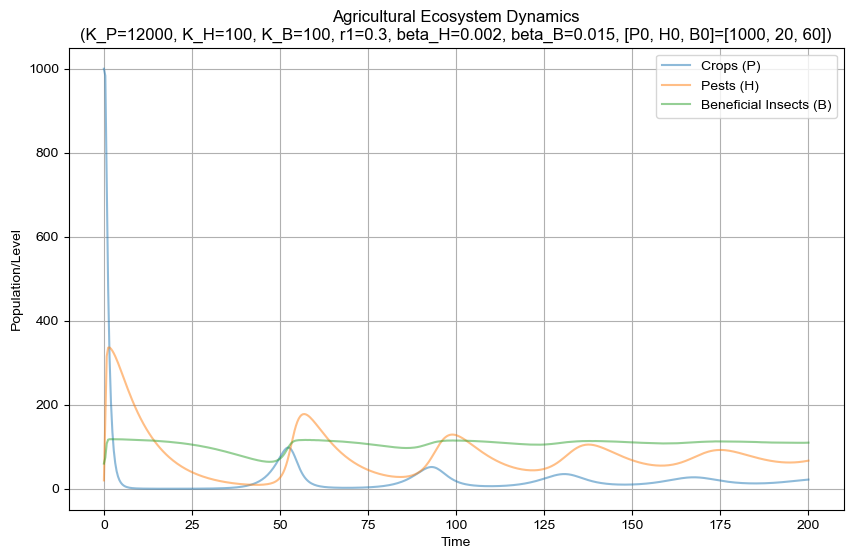

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib

# Solve the issue of negative signs in axis labels
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = ['Arial']

# Differential equations for the agricultural ecosystem
def agricultural_ecosystem(t, y, params):
    P, H, B = y  # P: Crops, H: Pests, B: Beneficial insects

    # Crop dynamics
    dPdt = (params['r1'] * P * (1 - P / params['K_P']) 
            - params['alpha_H'] * H * P
            - params['alpha_I'] * params['I0'] * P)

    
    # Pest dynamics
    dHdt = (params['beta_H'] * H * P * (1 - H / params['K_H']) 
            + params['gamma_H'] * P * H 
            - params['mu_H'] * H)

    # Beneficial insect dynamics
    dBdt = (params['beta_B'] * B * H * (1 - B / params['K_B']) 
            + params['gamma_B'] * H * B 
            - params['mu_B'] * B)

    return [dPdt, dHdt, dBdt]

# Parameters
params = {
    'r1': 0.3,       # Growth rate of crops
    'K_P': 12000,     # Carrying capacity of crops
    'alpha_H': 0.004, # Pest predation rate on crops
    'alpha_I': 0.002, # Photosynthesis inhibition parameter
    'I0': 0.2,       # Environmental light intensity
    'beta_H': 0.002,  # Birth rate of pests
    'K_H': 100,      # Carrying capacity of pests
    'gamma_H': 0.005, # Interaction effect of crops on pests
    'mu_H': 0.1,     # Death rate of pests
    'beta_B': 0.015, # Birth rate of beneficial insects
    'K_B': 100,      # Carrying capacity of beneficial insects
    'gamma_B': 0.003, # Interaction effect of pests on beneficial insects
    'mu_B': 0.1      # Death rate of beneficial insects
}

# Initial conditions
y0 = [1000, 20, 60]  # Initial values for P (crops), H (pests), B (beneficial insects)

# Time range
t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Solve the system of differential equations
solution = solve_ivp(
    agricultural_ecosystem,
    t_span,
    y0,
    args=(params,),
    t_eval=t_eval,
    method='RK45',
    dense_output=True  # Enable dense output for interpolation
)

# Extract the results
P, H, B = solution.y

# Generate a formatted string for the parameters
init_params = (
    f"K_P={params['K_P']}, K_H={params['K_H']}, K_B={params['K_B']}, "
    f"r1={params['r1']}, beta_H={params['beta_H']}, beta_B={params['beta_B']}, "
    f"[P0, H0, B0]={y0}"
)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t_eval, P, label='Crops (P)', alpha=0.5)
plt.plot(t_eval, H, label='Pests (H)', alpha=0.5)
plt.plot(t_eval, B, label='Beneficial Insects (B)', alpha=0.5)

plt.xlabel('Time')
plt.ylabel('Population/Level')
plt.title(f"Agricultural Ecosystem Dynamics\n({init_params})")  # Add params to the title
plt.legend(loc='upper right')
plt.grid()
plt.show()


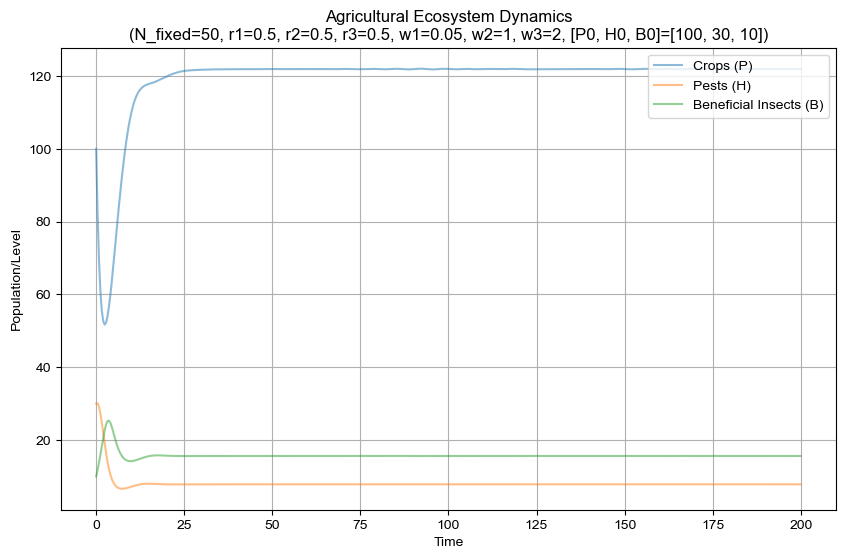

In [154]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib

# Solve the issue of negative signs in axis labels
matplotlib.rcParams['axes.unicode_minus'] = False
# Set font family
plt.rcParams['font.family'] = ['Arial']


# Differential equations for the agricultural ecosystem
def agricultural_ecosystem(t, y, params):
    P, H, B = y  # N is now a fixed parameter

    N = params['N_fixed']  # Use a fixed value for N

    dPdt = (params['r1'] * (N - params['w1'] * H * P) 
            - params['G'] * P)
    
    dHdt = (params['r2'] * H * (1 - H / (params['w2'] * P)) 
            - params['beta'] * B * H)
    
    dBdt = (params['r3'] * B * (1 - B / (params['w3'] * H)))
    
    return [dPdt, dHdt, dBdt]


params = {
    'r1': 0.5,       # Growth rate of crops
    'r2': 0.5,      # Growth rate of pests
    'r3': 0.5,      # Growth rate of beneficial insects
    'w1': 0.05,     # Interaction coefficient between pests and crops
    'w2': 1,      # Interaction coefficient between crops and pests
    'w3': 2,      # Interaction coefficient between pests and beneficial insects
    'beta': 0.03,    # Impact of beneficial insects on pests
    'G': 0.01,       # Seasonal harvesting rate
#     'mu_P': 0.01,    # Natural mortality rate of crops
#     'mu_H': 0.02,    # Natural mortality rate of pests
#     'mu_B': 0.01,    # Natural mortality rate of beneficial insects
    'N_fixed': 50,   # Fixed value for nutrients
}


# Initial conditions
y0 = [100, 30, 10]  # Initial values for P, H, B (no N)



# Time range
t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Solve the system of differential equations
solution = solve_ivp(
    agricultural_ecosystem,
    t_span,
    y0,
    args=(params,),
    t_eval=t_eval,
    method='RK45',
    dense_output=True  # Enable dense output for interpolation
)

# Interpolate solution to match t_eval
P, H, B = solution.sol(t_eval)

# Generate a formatted string for the parameters
init_params = (
    f"N_fixed={params['N_fixed']}, "
    f"r1={params['r1']}, r2={params['r2']}, r3={params['r3']}, "
    f"w1={params['w1']}, w2={params['w2']}, w3={params['w3']}, "
    f"[P0, H0, B0]={y0}"
)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t_eval, P, label='Crops (P)', alpha=0.5)
plt.plot(t_eval, H, label='Pests (H)', alpha=0.5)
plt.plot(t_eval, B, label='Beneficial Insects (B)', alpha=0.5)


plt.xlabel('Time')
plt.ylabel('Population/Level')
plt.title(f"Agricultural Ecosystem Dynamics\n({init_params})")  # Add params to the title
plt.legend(loc='upper right')
plt.grid()
plt.show()


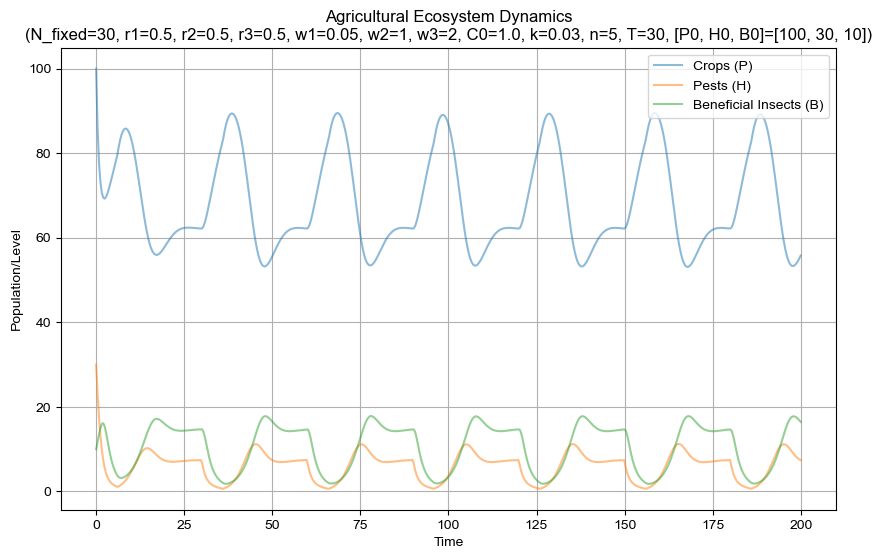

In [177]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib

# Solve the issue of negative signs in axis labels
matplotlib.rcParams['axes.unicode_minus'] = False
# Set font family
plt.rcParams['font.family'] = ['Arial']

# Define C(t) based on the given formula
def compute_C(t, C0, k, n, T):
    return sum(C0 * np.exp(-k * i * T) for i in range(1, n + 1) if t % T < T/n)

# Differential equations for the agricultural ecosystem
def agricultural_ecosystem(t, y, params):
    P, H, B = y  # Unpack state variables

    # Compute C(t)
    C_t = compute_C(t, params['C0'], params['k'], params['n'], params['T'])

    # Update equations to include C(t)
    dPdt = (params['r1'] / (1 + C_t)) * (P * (1 - P / params['K_P']) - params['w1'] * H * P - params['G'] * P)
    dHdt = (params['r2'] * H * (1 - H / (params['w2'] * P))) - params['beta'] * B * H - C_t * H
    dBdt = (params['r3'] * B * (1 - B / (params['w3'] * H)))

    return [dPdt, dHdt, dBdt]

# Parameters
params = {
    'r1': 0.5,       # Growth rate of crops
    'r2': 0.5,      # Growth rate of pests
    'r3': 0.5,      # Growth rate of beneficial insects
    'w1': 0.05,     # Interaction coefficient between pests and crops
    'w2': 1,        # Interaction coefficient between crops and pests
    'w3': 2,        # Interaction coefficient between pests and beneficial insects
    'beta': 0.03,    # Impact of beneficial insects on pests
    'G': 0.01,       # Seasonal harvesting rate
    'C0': 1.0,       # Initial value for C(t)
    'k': 0.03,        # Decay rate for C(t)
    'n': 5,          # Number of terms in the summation for C(t)
    'T': 30,         # Frequency of adding C0
    'K_P': 100,      # Carrying capacity for crops
    'N_fixed': 30,   # Fixed value for nutrients
}

# Initial conditions
y0 = [100, 30, 10]  # Initial values for P, H, B

# Time range
t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Solve the system of differential equations
solution = solve_ivp(
    agricultural_ecosystem,
    t_span,
    y0,
    args=(params,),
    t_eval=t_eval,
    method='RK45',
    dense_output=True  # Enable dense output for interpolation
)

# Interpolate solution to match t_eval
P, H, B = solution.sol(t_eval)

# Generate a formatted string for the parameters
init_params = (
    f"N_fixed={params['N_fixed']}, "
    f"r1={params['r1']}, r2={params['r2']}, r3={params['r3']}, "
    f"w1={params['w1']}, w2={params['w2']}, w3={params['w3']}, "
    f"C0={params['C0']}, k={params['k']}, n={params['n']}, T={params['T']}, "
    f"[P0, H0, B0]={y0}"
)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t_eval, P, label='Crops (P)', alpha=0.5)
plt.plot(t_eval, H, label='Pests (H)', alpha=0.5)
plt.plot(t_eval, B, label='Beneficial Insects (B)', alpha=0.5)

plt.xlabel('Time')
plt.ylabel('Population/Level')
plt.title(f"Agricultural Ecosystem Dynamics\n({init_params})")  # Add params to the title
plt.legend(loc='upper right')
plt.grid()
plt.show()


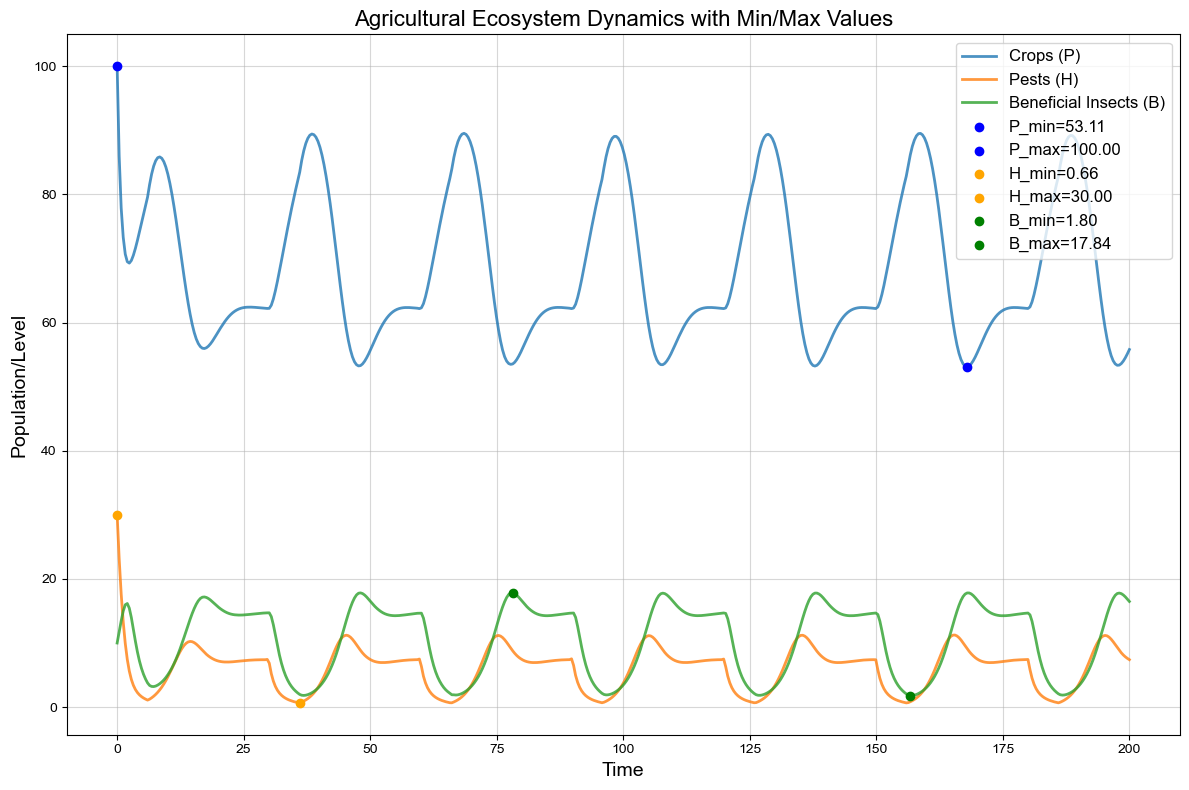

In [178]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib

# Solve the issue of negative signs in axis labels
matplotlib.rcParams['axes.unicode_minus'] = False
# Set font family
plt.rcParams['font.family'] = ['Arial']

# Define C(t) based on the given formula
def compute_C(t, C0, k, n, T):
    return sum(C0 * np.exp(-k * i * T) for i in range(1, n + 1) if t % T < T/n)

# Differential equations for the agricultural ecosystem
def agricultural_ecosystem(t, y, params):
    P, H, B = y  # Unpack state variables

    # Compute C(t)
    C_t = compute_C(t, params['C0'], params['k'], params['n'], params['T'])

    # Update equations to include C(t)
    dPdt = (params['r1'] / (1 + C_t)) * (P * (1 - P / params['K_P']) - params['w1'] * H * P - params['G'] * P)
    dHdt = (params['r2'] * H * (1 - H / (params['w2'] * P))) - params['beta'] * B * H - C_t * H
    dBdt = (params['r3'] * B * (1 - B / (params['w3'] * H)))

    return [dPdt, dHdt, dBdt]

# Parameters
params = {
    'r1': 0.5,       # Growth rate of crops
    'r2': 0.5,      # Growth rate of pests
    'r3': 0.5,      # Growth rate of beneficial insects
    'w1': 0.05,     # Interaction coefficient between pests and crops
    'w2': 1,        # Interaction coefficient between crops and pests
    'w3': 2,        # Interaction coefficient between pests and beneficial insects
    'beta': 0.03,    # Impact of beneficial insects on pests
    'G': 0.01,       # Seasonal harvesting rate
    'C0': 1.0,       # Initial value for C(t)
    'k': 0.03,       # Decay rate for C(t)
    'n': 5,          # Number of terms in the summation for C(t)
    'T': 30,         # Frequency of adding C0
    'K_P': 100,      # Carrying capacity for crops
    'N_fixed': 30,   # Fixed value for nutrients
}

# Initial conditions
y0 = [100, 30, 10]  # Initial values for P, H, B

# Time range
t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Solve the system of differential equations
solution = solve_ivp(
    agricultural_ecosystem,
    t_span,
    y0,
    args=(params,),
    t_eval=t_eval,
    method='RK45',
    dense_output=True  # Enable dense output for interpolation
)

# Interpolate solution to match t_eval
P, H, B = solution.sol(t_eval)

# Calculate min and max values for each population
P_min, P_max = P.min(), P.max()
H_min, H_max = H.min(), H.max()
B_min, B_max = B.min(), B.max()

# Plot results with min/max annotations
plt.figure(figsize=(12, 8))
plt.plot(t_eval, P, label='Crops (P)', alpha=0.8, linewidth=2)
plt.plot(t_eval, H, label='Pests (H)', alpha=0.8, linewidth=2)
plt.plot(t_eval, B, label='Beneficial Insects (B)', alpha=0.8, linewidth=2)

# Annotate min/max values for each population
plt.scatter([t_eval[np.argmin(P)]], [P_min], color='blue', label=f'P_min={P_min:.2f}', zorder=5)
plt.scatter([t_eval[np.argmax(P)]], [P_max], color='blue', label=f'P_max={P_max:.2f}', zorder=5)
plt.scatter([t_eval[np.argmin(H)]], [H_min], color='orange', label=f'H_min={H_min:.2f}', zorder=5)
plt.scatter([t_eval[np.argmax(H)]], [H_max], color='orange', label=f'H_max={H_max:.2f}', zorder=5)
plt.scatter([t_eval[np.argmin(B)]], [B_min], color='green', label=f'B_min={B_min:.2f}', zorder=5)
plt.scatter([t_eval[np.argmax(B)]], [B_max], color='green', label=f'B_max={B_max:.2f}', zorder=5)

# Add labels and grid
plt.xlabel('Time', fontsize=14)
plt.ylabel('Population/Level', fontsize=14)
plt.title('Agricultural Ecosystem Dynamics with Min/Max Values', fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()


In [232]:
!pip install pymoo

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.9 MB/s eta 0:00:00a 0:00:01
  Created wheel for grapheme: filename=grapheme-0.6.0-py3-none-any.whl size=210082 sha256=2832c72b087ef3d9a6fd1f807c6384b46b432ba5d5ab1cbdd019364ca58bb1c4
  Stored in directory: /Users/weiyuhan/Library/Caches/pip/wheels/ee/3b/0b/1b865800e916d671a24028d884698674138632a83fdfad4926
Successfully built grapheme


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import seaborn as sns

# Solve the issue of negative signs in axis labels
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = ['Arial']

# Define pesticide concentration based on decision variables
def compute_C(t, x, C0, k, T):
    # C(t) is now determined by pesticide inputs x
    print("hi")
    return sum(x[i] * C0 * np.exp(-k * (t - i * T)) for i in range(len(x)) if t >= i * T)

# Differential equations for the agricultural ecosystem
def agricultural_ecosystem(t, y, params, x):
    P, H, B = y  # Unpack state variables
    C_t = compute_C(t, x, params['C0'], params['k'], params['T'])  # Compute pesticide concentration

    # Update equations to include C(t)
    dPdt = (params['r1'] / (1 + (params['C_w1'] * C_t)**2)) * (P * (1 - P / params['K_P']) - params['w1'] * H * P - params['G'] * P)
    dHdt = (params['r2'] * H * (1 - H / (params['w2'] * P))) - params['beta'] * B * H - params['C_w2'] * C_t * H
    dBdt = (params['r3'] * B * (1 - B / (params['w3'] * H)))
    return [dPdt, dHdt, dBdt]

# Harvest event detection (event function must take only t and y)
def harvest_event_factory(params):
    # Define harvest times: t_autumn = 52/4*3 + k*52
    harvest_times = [39 + k * 52 for k in range(4)]  # 39 represents the 3rd quarter of each year

    def harvest_event(t, y):
        # Find the closest harvest time
        closest_harvest = min(harvest_times, key=lambda ht: abs(t - ht))
        return t - closest_harvest  # Event occurs when this value is 0

    harvest_event.terminal = False  # Event doesn't stop the integration
    harvest_event.direction = 0  # Trigger event in both directions
    return harvest_event

# Reset P after harvest
def apply_harvest(t, y, params):
    y[0] *= (1 - 0.85)  # Reduce P by 85%
    return y

# Parameters
params = {
    'r1': 0.5,       # Growth rate of crops
    'r2': 0.5,      # Growth rate of pests
    'r3': 0.5,      # Growth rate of beneficial insects
    'w1': 0.05,     # Interaction coefficient between pests and crops
    'w2': 1,        # Interaction coefficient between crops and pests
    'w3': 2,        # Interaction coefficient between pests and beneficial insects
    'beta': 0.03,    # Impact of beneficial insects on pests
    'G': 0.01,       # Seasonal harvesting rate
    'C0': 1.0,       # Initial value for C(t)
    'C_w1': 100,    # Chemical impact on nutrients
    'C_w2': 0.5,    # Chemical impact on pest
    'k': 0.03,       # Decay rate for C(t)
    'T': 13,         # Frequency of adding C0 (quarterly in weeks)
    'K_P': 100,      # Carrying capacity for crops
}

# Decision variables (pesticide inputs per quarter)
x = [1.5] * 16  # Example: constant pesticide input of 1.5 per quarter

# Initial conditions
y0 = [100, 30, 10]  # Initial values for [P, H, B]
t_span = (0, 208)  # 4 years in quarters
t_eval = np.linspace(t_span[0], t_span[1], 210)

# Create the harvest event function
harvest_event = harvest_event_factory(params)

# Solve the ODE with harvest events
solution = solve_ivp(
    agricultural_ecosystem,
    t_span,
    y0,
    args=(params, x),
    t_eval=t_eval,
    events=harvest_event,
    method='RK45',
    dense_output=True
)

# Apply harvest adjustments
for t_harvest in solution.t_events[0]:
    idx = np.searchsorted(t_eval, t_harvest)
    solution.y[:, idx:] = apply_harvest(t_harvest, solution.y[:, idx:], params)

# Plot results
P, H, B = solution.y
plt.figure(figsize=(14, 8))
plt.plot(t_eval, P, label='Crops (P)', color='green', linewidth=2)
plt.plot(t_eval, H, label='Pests (H)', color='red', linewidth=2)
plt.plot(t_eval, B, label='Beneficial Insects (B)', color='blue', linewidth=2)
plt.xlabel('Time (quarters)', fontsize=14)
plt.ylabel('Population/Level', fontsize=14)
plt.title('Agricultural Ecosystem Dynamics with Harvest Events', fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()


Frequency 10: Mean Pesticide Concentration = 0.4485
Frequency 20: Mean Pesticide Concentration = 0.2335
Frequency 30: Mean Pesticide Concentration = 0.1423
Frequency 40: Mean Pesticide Concentration = 0.0868
Frequency 50: Mean Pesticide Concentration = 0.0580


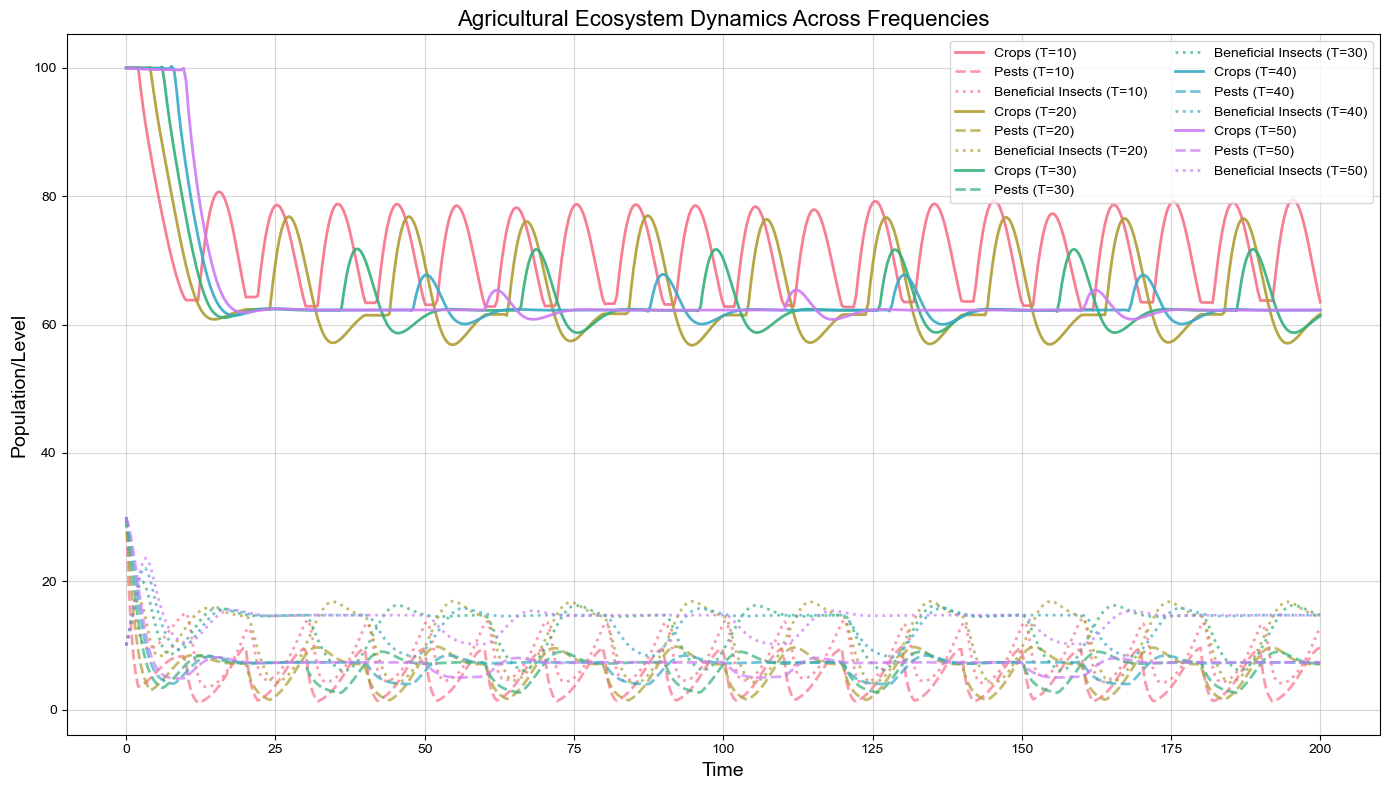

In [228]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib
import seaborn as sns

# Solve the issue of negative signs in axis labels
matplotlib.rcParams['axes.unicode_minus'] = False
# Set font family
plt.rcParams['font.family'] = ['Arial']

# Define C(t) based on the given formula
def compute_C(t, C0, k, n, T):
    # Cosine modulation for a yearly cycle (52 weeks)
    # amplitude_modulation = (1 - np.cos(2 * np.pi * t / 52))
    # Compute pesticide concentration
    # return sum(C0 * np.exp(-k * i * T) for i in range(1, n + 1) if t % T < T / n) * amplitude_modulation
    return sum(C0 * np.exp(-k * i * T) for i in range(1, n + 1) if t % T < T / n)

# Differential equations for the agricultural ecosystem
def agricultural_ecosystem(t, y, params):
    P, H, B = y  # Unpack state variables

    # Compute C(t)
    C_t = compute_C(t, params['C0'], params['k'], params['n'], params['T'])

    # Update equations to include C(t)
    dPdt = (params['r1'] / (1 + (params['C_w1'] * C_t)**2)) * (P * (1 - P / params['K_P']) - params['w1'] * H * P - params['G'] * P)
    dHdt = (params['r2'] * H * (1 - H / (params['w2'] * P))) - params['beta'] * B * H - params['C_w2'] * C_t * H
    dBdt = (params['r3'] * B * (1 - B / (params['w3'] * H)))

    return [dPdt, dHdt, dBdt]

# Parameters
params = {
    'r1': 0.5,       # Growth rate of crops
    'r2': 0.5,      # Growth rate of pests
    'r3': 0.5,      # Growth rate of beneficial insects
    'w1': 0.05,     # Interaction coefficient between pests and crops
    'w2': 1,        # Interaction coefficient between crops and pests
    'w3': 2,        # Interaction coefficient between pests and beneficial insects
    'beta': 0.03,    # Impact of beneficial insects on pests
    'G': 0.01,       # Seasonal harvesting rate
    'C0': 1.0,       # Initial value for C(t)
    'C_w1': 100,    # Chemical imapct on nutrients
    'C_w2': 0.5,    # Chemical imapct on pest
    'k': 0.03,       # Decay rate for C(t)
    'n': 5,          # Number of terms in the summation for C(t)
    'T': 30,         # Frequency of adding C0
    'K_P': 100,      # Carrying capacity for crops
    'N_fixed': 30,   # Fixed value for nutrients
}

# Frequencies to simulate
frequencies = [10, 20, 30, 40, 50]
results = {}
C_means = {}

# Time range
t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 500)

for freq in frequencies:
    params['T'] = freq
    solution = solve_ivp(
        agricultural_ecosystem,
        t_span,
        [100, 30, 10],
        args=(params,),
        t_eval=t_eval,
        method='RK45',
        dense_output=True
    )
    results[freq] = solution.sol(t_eval)

    # Compute the mean pesticide concentration for each frequency
    C_values = [compute_C(t, params['C0'], params['k'], params['n'], params['T']) for t in t_eval]
    C_means[freq] = np.mean(C_values)

# Print the mean pesticide concentrations
for freq, mean_C in C_means.items():
    print(f"Frequency {freq}: Mean Pesticide Concentration = {mean_C:.4f}")

# Define vibrant colors for better aesthetics
colors = sns.color_palette("husl", len(frequencies))

# Plot results for each frequency
plt.figure(figsize=(14, 8))
for i, freq in enumerate(frequencies):
    P, H, B = results[freq]
    plt.plot(t_eval, P, label=f'Crops (T={freq})', color=colors[i], alpha=0.9, linewidth=2)
    plt.plot(t_eval, H, '--', label=f'Pests (T={freq})', color=colors[i], alpha=0.7, linewidth=2)
    plt.plot(t_eval, B, ':', label=f'Beneficial Insects (T={freq})', color=colors[i], alpha=0.7, linewidth=2)

# Add labels and grid
plt.xlabel('Time', fontsize=14)
plt.ylabel('Population/Level', fontsize=14)
plt.title('Agricultural Ecosystem Dynamics Across Frequencies', fontsize=16)
plt.legend(loc='upper right', fontsize=10, ncol=2)
plt.grid(alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()


Frequency 10: Mean Pesticide Concentration = 0.4485
Frequency 20: Mean Pesticide Concentration = 0.2335
Frequency 30: Mean Pesticide Concentration = 0.1423
Frequency 40: Mean Pesticide Concentration = 0.0868
Frequency 50: Mean Pesticide Concentration = 0.0580


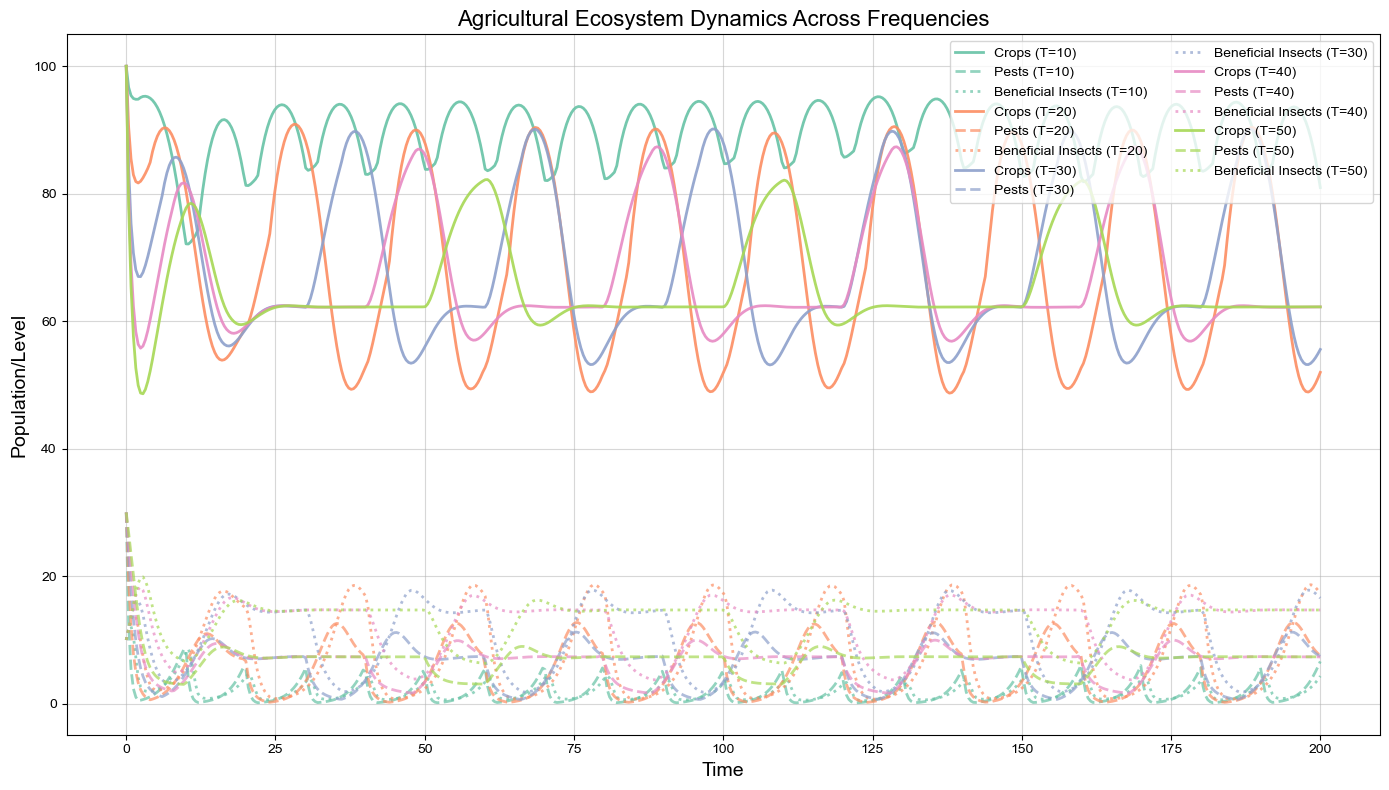

In [193]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib
import seaborn as sns

# Solve the issue of negative signs in axis labels
matplotlib.rcParams['axes.unicode_minus'] = False
# Set font family
plt.rcParams['font.family'] = ['Arial']

# Define C(t) based on the given formula
def compute_C(t, C0, k, n, T):
    return sum(C0 * np.exp(-k * i * T) for i in range(1, n + 1) if t % T < T/n)

# Differential equations for the agricultural ecosystem
def agricultural_ecosystem(t, y, params):
    P, H, B = y  # Unpack state variables

    # Compute C(t)
    C_t = compute_C(t, params['C0'], params['k'], params['n'], params['T'])

    # Update equations to include C(t)
    dPdt = (params['r1'] / (1 + C_t**2)) * (P * (1 - P / params['K_P']) - params['w1'] * H * P - params['G'] * P)
    dHdt = (params['r2'] * H * (1 - H / (params['w2'] * P))) - params['beta'] * B * H - C_t * H
    dBdt = (params['r3'] * B * (1 - B / (params['w3'] * H)))

    return [dPdt, dHdt, dBdt]

# Parameters
params = {
    'r1': 0.5,       # Growth rate of crops
    'r2': 0.5,      # Growth rate of pests
    'r3': 0.5,      # Growth rate of beneficial insects
    'w1': 0.05,     # Interaction coefficient between pests and crops
    'w2': 1,        # Interaction coefficient between crops and pests
    'w3': 2,        # Interaction coefficient between pests and beneficial insects
    'beta': 0.03,    # Impact of beneficial insects on pests
    'G': 0.01,       # Seasonal harvesting rate
    'C0': 1.0,       # Initial value for C(t)
    'k': 0.03,       # Decay rate for C(t)
    'n': 5,          # Number of terms in the summation for C(t)
    'T': 30,         # Frequency of adding C0
    'K_P': 100,      # Carrying capacity for crops
    'N_fixed': 30,   # Fixed value for nutrients
}

# Frequencies to simulate
frequencies = [10, 20, 30, 40, 50]
results = {}
C_means = {}

# Time range
t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 500)

for freq in frequencies:
    params['T'] = freq
    solution = solve_ivp(
        agricultural_ecosystem,
        t_span,
        [100, 30, 10],
        args=(params,),
        t_eval=t_eval,
        method='RK45',
        dense_output=True
    )
    results[freq] = solution.sol(t_eval)

    # Compute the mean pesticide concentration for each frequency
    C_values = [compute_C(t, params['C0'], params['k'], params['n'], params['T']) for t in t_eval]
    C_means[freq] = np.mean(C_values)

# Print the mean pesticide concentrations
for freq, mean_C in C_means.items():
    print(f"Frequency {freq}: Mean Pesticide Concentration = {mean_C:.4f}")

# Use a color palette from seaborn for better aesthetics
palette = sns.color_palette("Set2", len(frequencies))

# Plot results for each frequency
plt.figure(figsize=(14, 8))
for i, freq in enumerate(frequencies):
    P, H, B = results[freq]
    plt.plot(t_eval, P, label=f'Crops (T={freq})', color=palette[i], alpha=0.9, linewidth=2)
    plt.plot(t_eval, H, '--', label=f'Pests (T={freq})', color=palette[i], alpha=0.7, linewidth=2)
    plt.plot(t_eval, B, ':', label=f'Beneficial Insects (T={freq})', color=palette[i], alpha=0.7, linewidth=2)

# Add labels and grid
plt.xlabel('Time', fontsize=14)
plt.ylabel('Population/Level', fontsize=14)
plt.title('Agricultural Ecosystem Dynamics Across Frequencies', fontsize=16)
plt.legend(loc='upper right', fontsize=10, ncol=2)
plt.grid(alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib

# Solve the issue of negative signs in axis labels
matplotlib.rcParams['axes.unicode_minus'] = False
# Set font family
plt.rcParams['font.family'] = ['Arial']


# Differential equations for the agricultural ecosystem
def agricultural_ecosystem(t, y, params):
    P, H, B = y  # N is now a fixed parameter

    N = params['N_fixed']  # Use a fixed value for N

    dPdt = (params['r1'] * (N  - params['w1'] * H * P) 
            - params['G'] * P)
    
    dHdt = (params['r2'] * H * (1 - H / params['K_H']) - params['beta'] * B * H)
    
    dBdt = (params['r3'] * B * (1 - B / params['K_B']))
    
    return [dPdt, dHdt, dBdt]


params = {
    'r1': 0.1,       # Growth rate of crops
    'r2': 0.5,      # Growth rate of pests
    'r3': 0.2,      # Growth rate of beneficial insects
    'w1': 0.05,     # Interaction coefficient between pests and crops
    'w2': 1,      # Interaction coefficient between crops and pests
    'w3': 2,      # Interaction coefficient between pests and beneficial insects
    'beta': 0.03,    # Impact of beneficial insects on pests
    'G': 0.01,       # Seasonal harvesting rate
#     'mu_P': 0.01,    # Natural mortality rate of crops
#     'mu_H': 0.02,    # Natural mortality rate of pests
#     'mu_B': 0.01,    # Natural mortality rate of beneficial insects
    'N_fixed': 50,   # Fixed value for nutrients
    'K_H': 100,      # Carrying capacity of pests
    'K_B': 100,      # Carrying capacity of beneficial insects
}


# Initial conditions
y0 = [100, 30, 10]  # Initial values for P, H, B (no N)



# Time range
t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Solve the system of differential equations
solution = solve_ivp(
    agricultural_ecosystem,
    t_span,
    y0,
    args=(params,),
    t_eval=t_eval,
    method='RK45',
    dense_output=True  # Enable dense output for interpolation
)

# Interpolate solution to match t_eval
P, H, B = solution.sol(t_eval)

# Generate a formatted string for the parameters
init_params = (
    f"N_fixed={params['N_fixed']}, "
    f"r1={params['r1']}, r2={params['r2']}, r3={params['r3']}, "
    f"w1={params['w1']}, w2={params['w2']}, w3={params['w3']}, "
    f"[P0, H0, B0]={y0}"
)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t_eval, P, label='Crops (P)', alpha=0.5)
plt.plot(t_eval, H, label='Pests (H)', alpha=0.5)
plt.plot(t_eval, B, label='Beneficial Insects (B)', alpha=0.5)

plt.xlabel('Time')
plt.ylabel('Population/Level')
plt.title(f"Agricultural Ecosystem Dynamics\n({init_params})")  # Add params to the title
plt.legend(loc='upper right')
plt.grid()
plt.show()


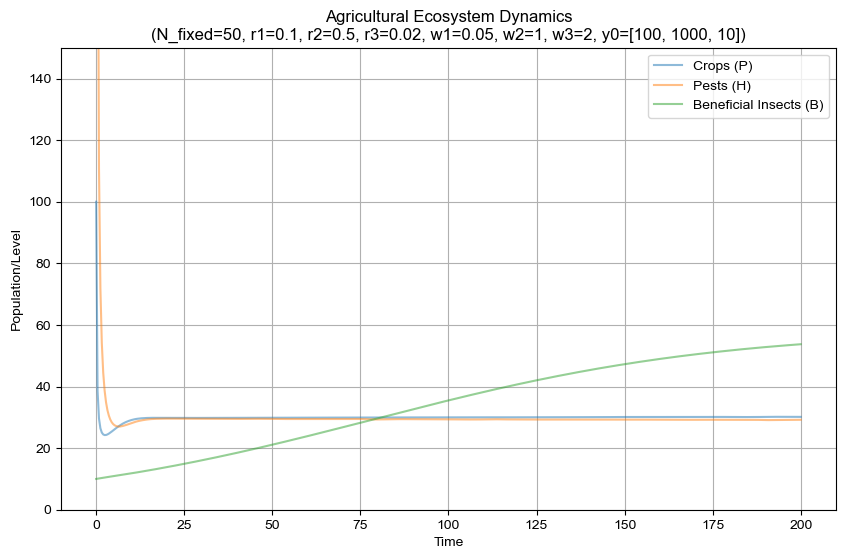

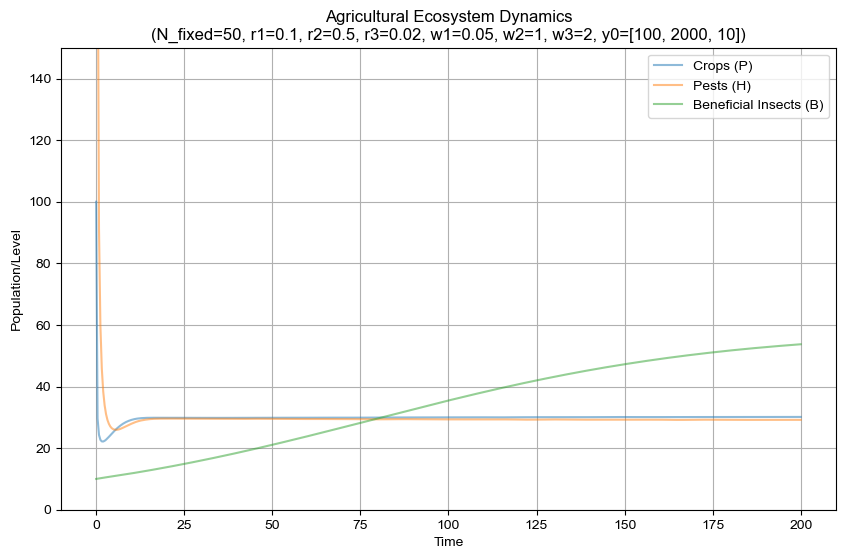

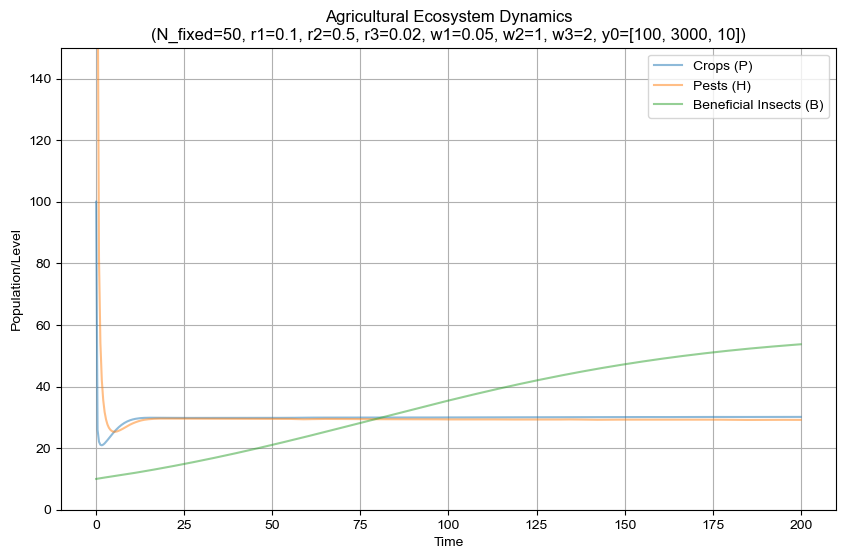

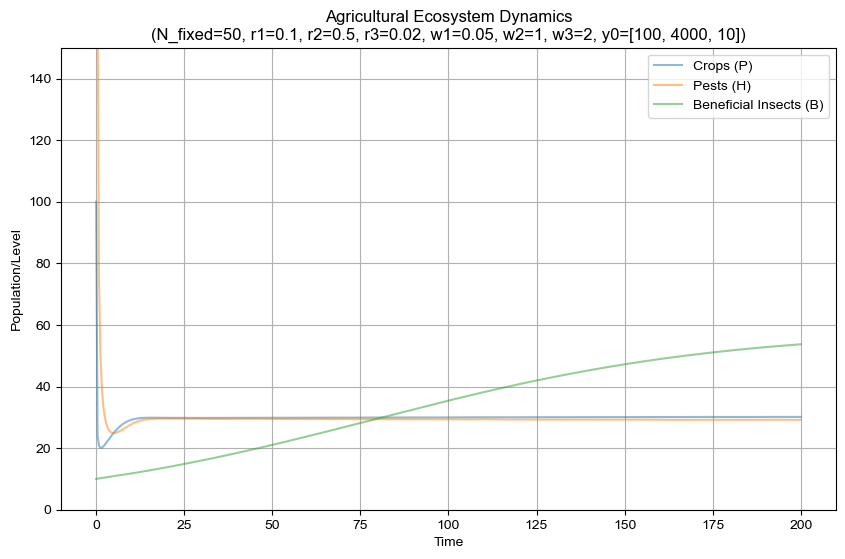

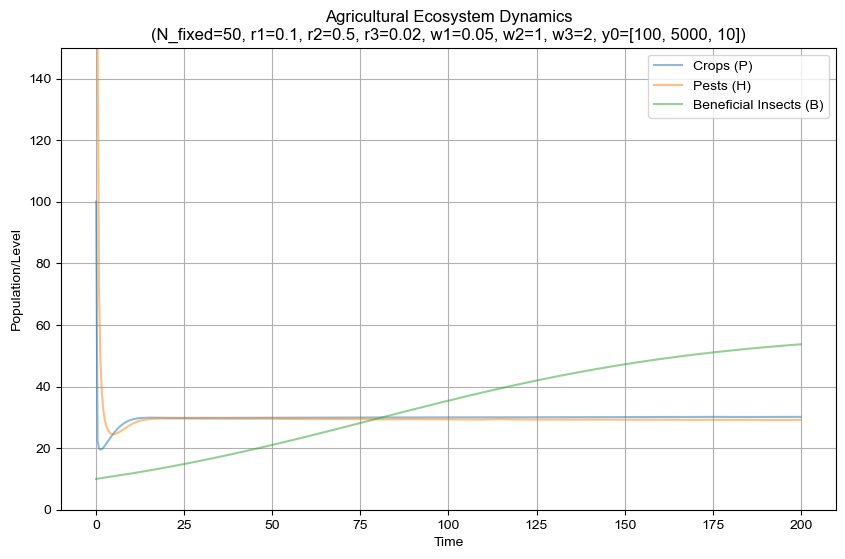

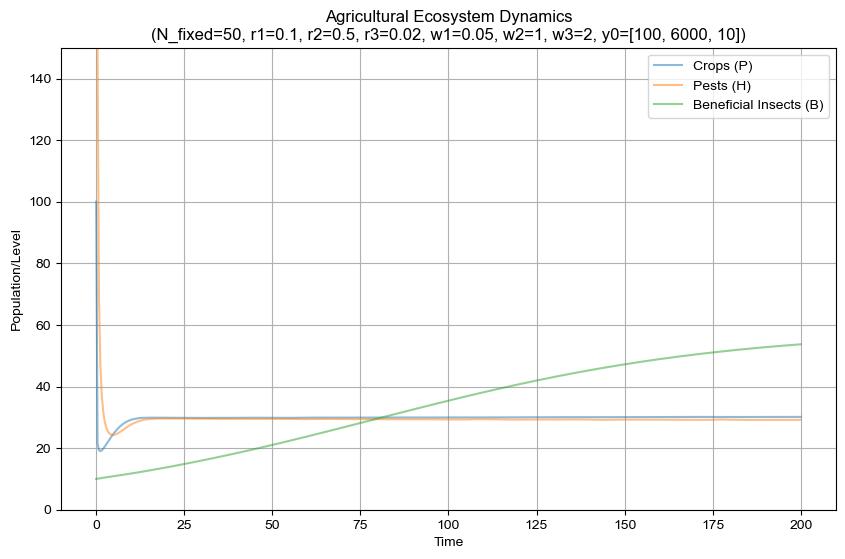

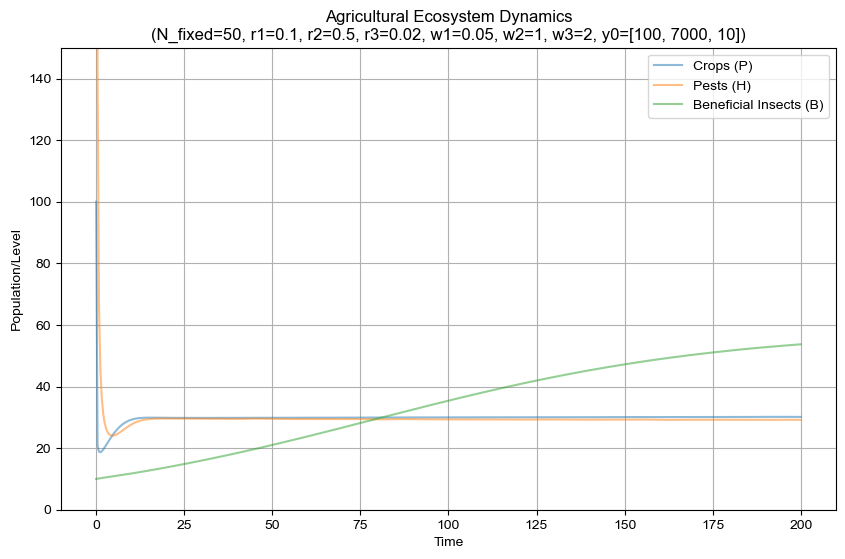

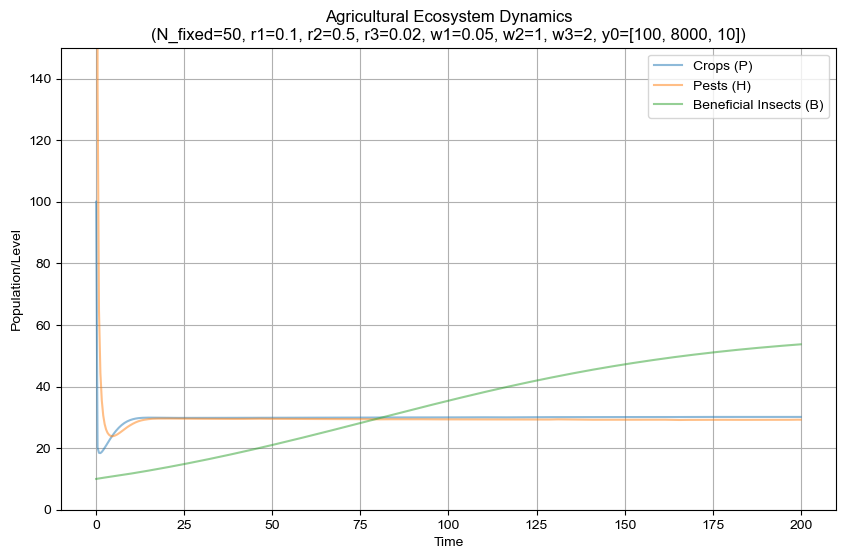

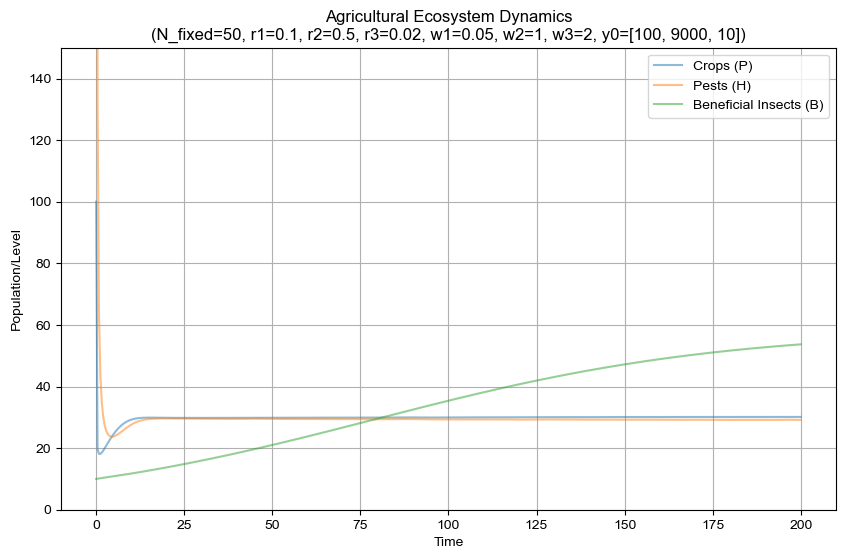

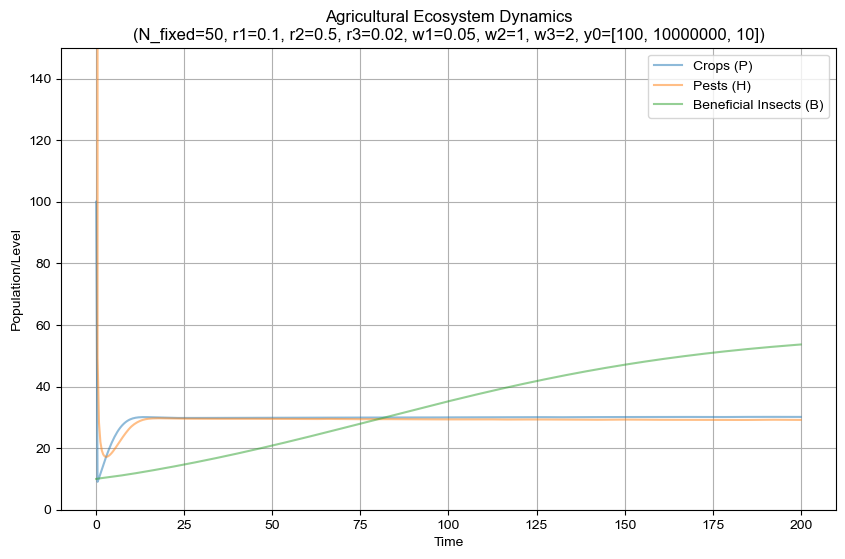

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib

# Solve the issue of negative signs in axis labels
matplotlib.rcParams['axes.unicode_minus'] = False
# Set font family
plt.rcParams['font.family'] = ['Arial']


# Differential equations for the agricultural ecosystem
def agricultural_ecosystem(t, y, params):
    P, H, B = y  # N is now a fixed parameter

    N = params['N_fixed']  # Use a fixed value for N

    dPdt = (params['r1'] * (N - params['w1'] * H * P) 
            - params['G'] * P 
            - params['mu_P'] * P)
    
    dHdt = (params['r2'] * H * (1 - H / (params['w2'] * P)) 
            - params['beta'] * B * H)
    
    dBdt = (params['r3'] * B * (1 - B / (params['w3'] * H)))
    
    return [dPdt, dHdt, dBdt]





params = {
    'r1': 0.1,       # Growth rate of crops
    'r2': 0.5,      # Growth rate of pests
    'r3': 0.02,      # Growth rate of beneficial insects
    'w1': 0.05,     # Interaction coefficient between pests and crops
    'w2': 1,      # Interaction coefficient between crops and pests
    'w3': 2,      # Interaction coefficient between pests and beneficial insects
    'beta': 0.0003,    # Impact of beneficial insects on pests
    'G': 0.01,       # Seasonal harvesting rate
    'mu_P': 0.01,    # Natural mortality rate of crops
    'mu_H': 0.02,    # Natural mortality rate of pests
    'mu_B': 0.01,    # Natural mortality rate of beneficial insects
    'N_fixed': 50,   # Fixed value for nutrients
}


# Time range
t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Initial conditions for pests (vary H initial value)
pest_initial_values = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000,  10000000]  # Different initial values for pests

# Loop through different initial pest values and plot
for H_init in pest_initial_values:
    y0 = [100, H_init, 10]  # Initial values for P, H, B
    
    # Solve the system of differential equations
    solution = solve_ivp(
        agricultural_ecosystem,
        t_span,
        y0,
        args=(params,),
        t_eval=t_eval,
        method='RK45',
        dense_output=True  # Enable dense output for interpolation
    )
    
    # Interpolate solution to match t_eval
    P, H, B = solution.sol(t_eval)
    
    # Generate a formatted string for the parameters
    init_params = (
        f"N_fixed={params['N_fixed']}, "
        f"r1={params['r1']}, r2={params['r2']}, r3={params['r3']}, "
        f"w1={params['w1']}, w2={params['w2']}, w3={params['w3']}, "
        f"y0={[100, H_init, 10]}"
    )
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(t_eval, P, label='Crops (P)', alpha=0.5)
    plt.plot(t_eval, H, label='Pests (H)', alpha=0.5)
    plt.plot(t_eval, B, label='Beneficial Insects (B)', alpha=0.5)
    plt.ylim(0, 150)
    
    plt.xlabel('Time')
    plt.ylabel('Population/Level')
    plt.title(f"Agricultural Ecosystem Dynamics\n({init_params})")  # Add params to the title
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()


-45000.0
0.03
-43471.3694838814
0.03000022838827204
-29370.194765523986
0.03000253645350715
-27952.748477422003
0.030003801530159784
-2940.0392172011957
0.0300101427612864
-11320.157839037936
-1.20778997879067
-4863.5434290659105
-0.7483872720612794
-20815.85679683069
0.030012542363102124
-35824.123786624776
0.030001429406045124
-33547.01565260095
0.030002143209412017
-18575.125144278816
0.03000571410062981
-10802.236200600326
0.030006353627479658
-9676.911165682795
0.030007148062178395
-19043.693464786455
0.030007138842891003
-16412.37372782487
0.030008564755489787
-15556.223214905485
0.030009276855639547
-11015.48456369214
0.030012838165908485
-9456.823331333388
0.030013473614537014
-8871.391906556593
0.030014264240828554
-10300.721513315142
0.030014259709606052
-8285.063001801847
0.03001699357621846
-7766.908591295347
0.030018357306702593
-4460.865327816943
0.030025182292054857
-2792.64314018552
0.030026411054129294
-2517.803076361784
0.030027928988462207
-4487.515936951783
0.030027

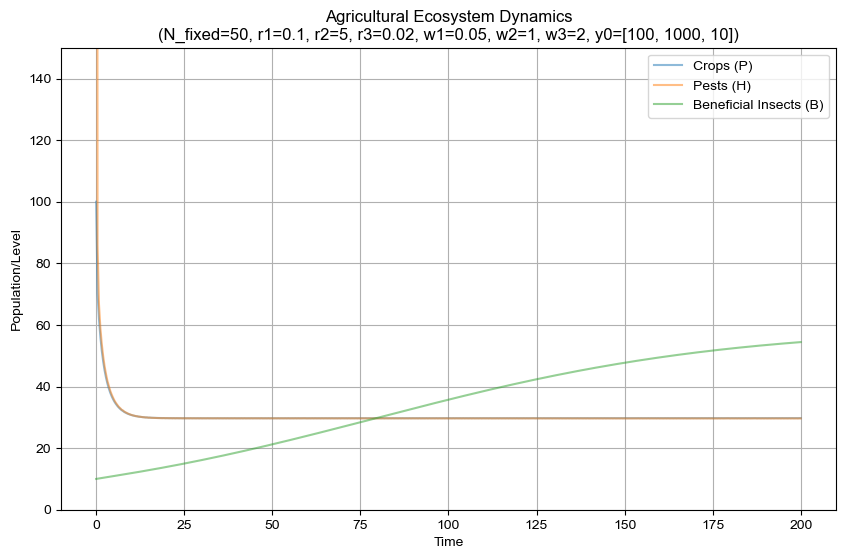

-190000.0
0.03
-183691.31615041467
0.030000108519252264
-93982.96747453533
0.0300018947665984
-100291.82069672273
0.030002839986047164
-67345.70418263841
-3.0947690408658484
-1808916.3089380523
-14.744887313815383
-585718.76263099
0.030009513177000628
-3916929.5671938453
0.03000950677731001
-156088.73435952768
0.030000604387835493
-146659.2925492413
0.030000906414579694
-90637.47433422241
0.030002416814463022
-65166.237076143494
0.030002686023905364
-59667.25888438076
0.030003021648610392
-87998.37821376105
0.03000302030706875
-76932.15992166266
0.030003624023746026
-73160.9598666616
0.030003925717374556
-53714.74832664991
0.030005434301703562
-47713.6734644949
0.03000570287660306
-45033.892326014895
0.030006037950651626
-50025.02085601771
0.03000603718968167
-40122.033884236145
0.03000730081573649
-37594.337980270706
0.030007931866003965
-21424.594627591698
0.030011088607795423
-13265.490638397576
0.03001165356209822
-11956.914403767782
0.03001235554684912
-21614.59881623291
0.0300123

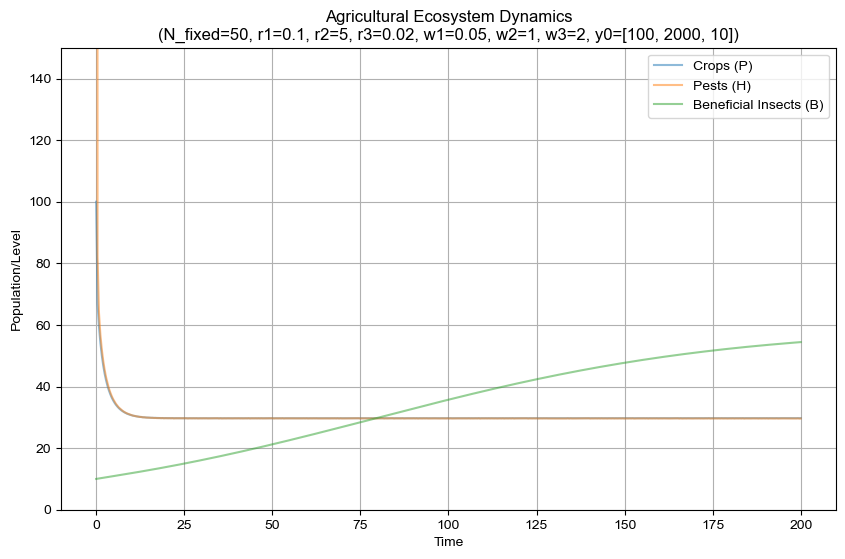

-435000.0
0.03
-420660.9552644926
0.030000071170719272
-190616.2274389558
0.03000142341438535
-219447.73963893816
0.030002133791894394
-516494.9205358188
-8.608655836239134
-8667439.90633851
-29.482858003203432
-21511189.75208797
0.03000714247815775
-515946.5974508789
-8.726836961674978
-372675.2143736964
0.030000317666453037
-352742.1908132958
0.030000476453756
-246032.38909518564
0.03000127043527961
-208161.57294993591
0.030001411719699972
-194783.73223927326
0.030001588121130688
-230489.67780019835
0.03000158786318611
-205800.6763806645
0.030001905340248956
-196822.91900016385
0.03000206403285081
-151932.2416258178
0.030002857514215133
-140059.68337307012
0.03000299865928805
-133289.59875075682
0.03000317493742377
-141460.24953506602
0.030003174767264804
-112832.19850393965
0.030003948633497732
-105663.56617961658
0.030004335271806078
-59039.42682028314
0.030006269057278715
-35115.77448141746
0.03000661435356211
-31535.628048010563
0.030007044365117926
-60179.2040246219
0.0300070413

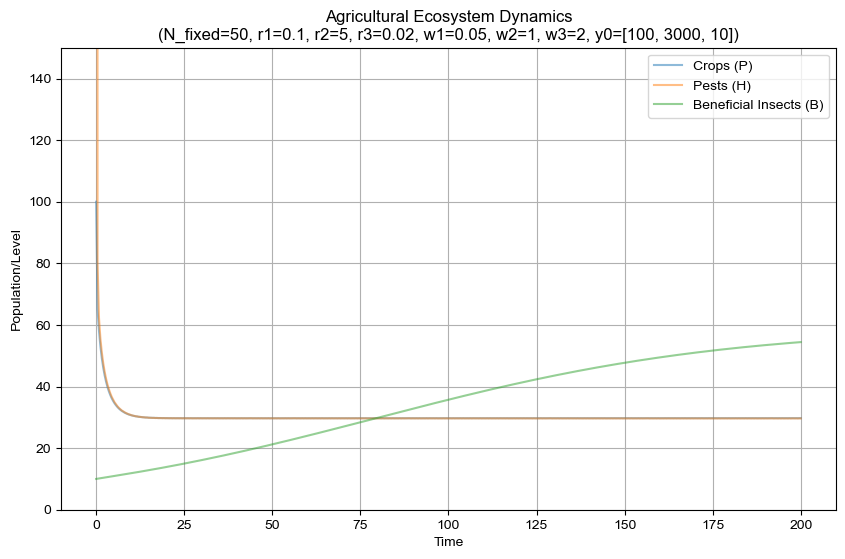

-780000.0
0.03
-754380.2575979965
0.030000052948380783
-343107.0965126132
0.03000105896761564
-393901.15222521086
0.030001587709418936
-895867.784885978
-11.388251654568386
-15206164.22558449
-39.24889415012522
-35770185.21288101
0.03000530894278949
-126345.52664245959
-4.259994416211532
-666411.1331154965
0.030000241223754616
-630396.9558148643
0.03000036180887903
-436526.75089947355
0.030000964761660826
-366490.49235540535
0.0300010720323058
-342514.8510217133
0.03000120599996035
-409467.3428844943
0.030001205845893
-365067.511153418
0.03000144695933928
-348992.0336504206
0.03000156748923533
-268477.98790353205
0.03000217014987572
-246966.0177727326
0.030002277338206717
-234895.67617525643
0.030002411233074594
-249923.33411011606
0.030002411132068117
-199452.9270538814
0.030002991809074248
-186784.73559516115
0.030003281979122897
-104599.10494642406
0.030004733166009552
-62543.19989178402
0.030004992015923167
-56195.62311540599
0.0300053146620152
-106468.66873701851
0.030005312966278

0.28092939906650993
0.3355460998555002
0.2538807170887629
0.33577792925069294
0.9913893002357752
0.3348815299076433
2.933177167079278
0.33036279170530336
3.8596263107421187
0.3282687804578216
0.1757916429753482
0.33713989765320745
0.28333977304956753
0.33722372958386276
0.2566898827949699
0.3374542661599421
0.9835956855565053
0.3365710300410247
2.8978087040939395
0.3320965688666713
3.8116987020778765
0.3300230308929373
0.17974725371565253
0.3388097227404376
0.28604712444001923
0.3388948121299542
0.25950329316862425
0.3391251922453401
0.9815949189432741
0.3382438040278736
2.886050493198958
0.33377047526493336
3.7988091037214224
0.3316888233855517
0.18119712962842097
0.3404832338140067
0.2878947442324568
0.3405655982255064
0.2610620026420586
0.34079669814673147
0.9891466622508905
0.3398910372083022
2.9115443276005917
0.33534993055723833
3.8353071529795373
0.3332283337063462
0.18049933820025896
0.34215906495835724
0.288726742001866
0.3422350125564896
0.26154620713655424
0.3424664830937938

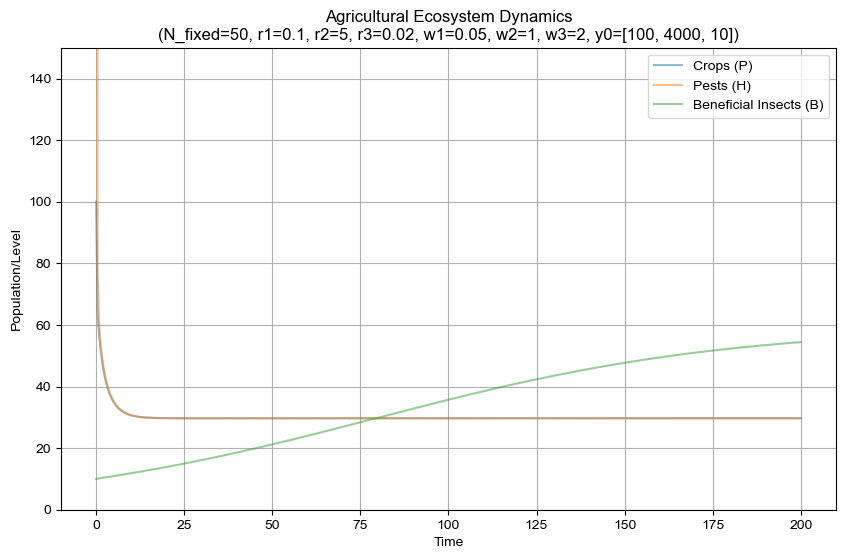

-1225000.0
0.03
-1184849.2177904057
0.030000042155233372
-540075.6915596646
0.03000084310466742
-619011.444804083
0.030001264184371816
-1379298.6652312474
-14.16898102395855
-23572638.0308277
-49.01333775943847
-53696436.59070172
0.030004224480057108
-570.7919939250539
-0.1941150951331616
-1044426.5360511171
0.03000019490577099
-987553.4135260493
0.030000292341079947
-680066.5560461008
0.030000779535948225
-567488.0636548505
0.030000866201335224
-529859.5536628483
0.030000974452935543
-638580.7435374658
0.030000974349792136
-568704.9426396152
0.030001169183115236
-543488.5353166801
0.030001266582123993
-417027.8215217874
0.030001753584739544
-382976.8294268003
0.030001840195470236
-364103.86272814096
0.03000194839877504
-388156.5254447795
0.030001948331500924
-309890.7866210207
0.030002413383252022
-290213.4274874078
0.030002645800111923
-162772.3228122955
0.030003808101112483
-97677.55799911752
0.03000401528829905
-87794.12525328522
0.030004273680405022
-165522.73876229342
0.030004272

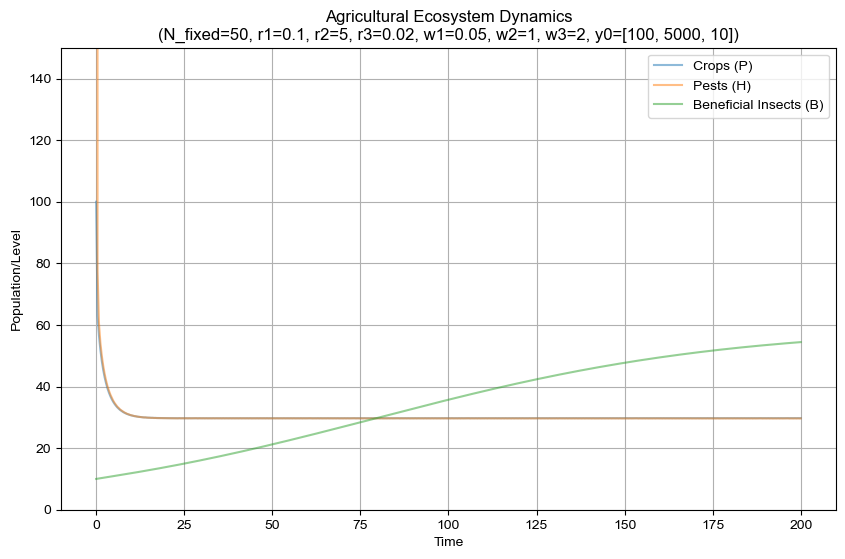

-1770000.0
0.03
-1712067.8341164805
0.03000003501726563
-781521.9948103313
0.030000700345312666
-894778.564137791
0.03000105019078944
-1966780.0406291585
-16.95026556007161
-33766836.49940001
-58.77703150179754
-75286525.41135804
0.030003507914315997
-82798.05557905695
0.03000350436441143
-1506695.7342658173
0.030000163677868705
-1424185.9021401363
0.03000024550435386
-976589.495353277
0.030000654650019352
-811045.6687771437
0.030000727425105518
-756713.6198436065
0.030000818336744197
-917795.4952908085
0.030000818262641987
-816679.9920036191
0.030000981889213407
-780280.8359830166
0.030001063689983003
-597554.2616702401
0.030001472699324433
-548062.1791776272
0.030001545435383564
-520885.6553819179
0.030001636312556115
-556136.4340728781
0.03000163626442039
-444126.8998959509
0.030002024231182433
-415931.9858371249
0.030002218138236874
-233548.70010356168
0.03000318782465973
-140512.0289672359
0.030003360601843092
-126325.0180561025
0.03000357615942783
-237331.30054664912
0.0300035753

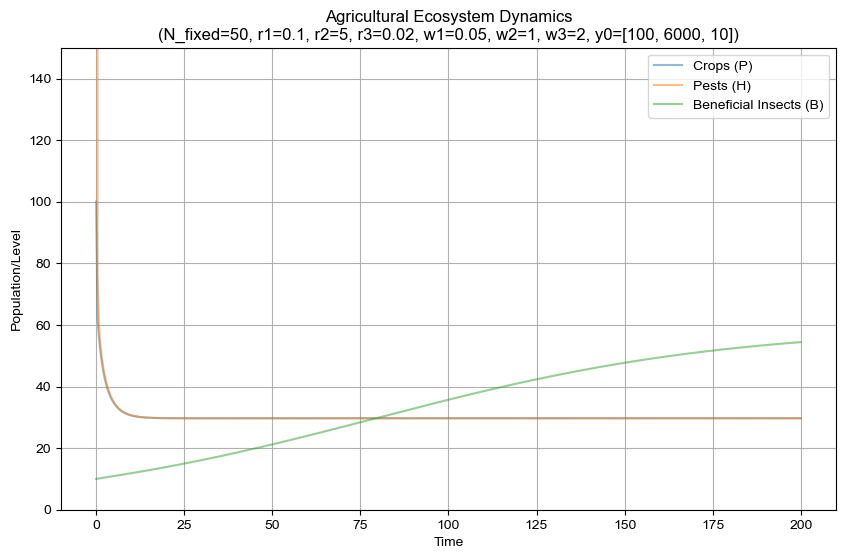

-2415000.0
0.03
-2336036.1058513653
0.030000029946561334
-1067445.9988032237
0.030000598931226627
-1221202.4878752641
0.030000898157003523
-2658308.7848796532
-19.73186316698451
-45788748.95524811
-68.54031308392348
-100539046.90564743
0.03000299918546871
-351850.751915024
0.03000299659141646
-2053202.55180323
0.03000014114803844
-1940277.9911829385
0.030000211712770685
-1326055.9836504825
0.030000564546461654
-1097095.8506997623
0.03000062730118772
-1023012.1010190933
0.030000705701644412
-1247088.4806217258
0.030000705645750626
-1108970.1317291574
0.03000084675553254
-1059347.1796750084
0.03000091730107973
-810037.6953314998
0.030001270032990066
-742200.8420617082
0.030001332758417387
-705220.6780430877
0.03000141113300971
-753845.9123558355
0.030001411096819967
-602147.5885908797
0.030001743962004303
-563927.6207703728
0.03000191033816878
-316921.0510488864
0.030002742330422483
-191042.29562861394
0.030002890526951643
-171784.45148224875
0.030003075466885805
-321887.1375703836
0.030

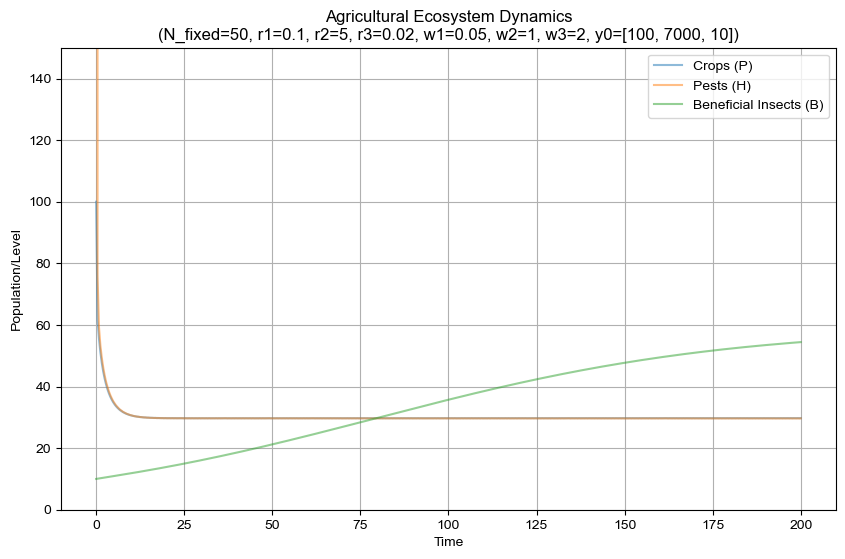

-3160000.0
0.03
-3056754.0326373
0.03000002615864636
-1397847.6998571374
0.030000523172927156
-1598283.2049902861
0.03000078457607509
-3453883.3657193943
-22.51365464715301
-59638370.05260103
-78.30334401645602
-129453317.77131155
0.03000261932283154
-797959.1124479104
0.030002617344773396
-2683936.8463522717
0.03000012410644039
-2535819.3300373424
0.03000018615246363
-1728441.1083337148
0.03000049639044755
-1425596.4952192705
0.0300005515663416
-1328714.4207955243
0.030000620502760908
-1626444.9242002745
0.03000062045906318
-1445560.8903754803
0.030000744535863745
-1380673.554133703
0.03000080656701908
-1054465.3496270212
0.03000111672607806
-965379.0227460848
0.030001171879151592
-917095.6533752948
0.030001240795431244
-981273.7038263507
0.030001240767212858
-783943.9051818126
0.030001532267544165
-734191.9665268105
0.03000167797429458
-412884.7415439425
0.030002406593595533
-249265.6571896836
0.030002536346325884
-224170.0217237669
0.03000269830216272
-419185.5509717051
0.0300026978

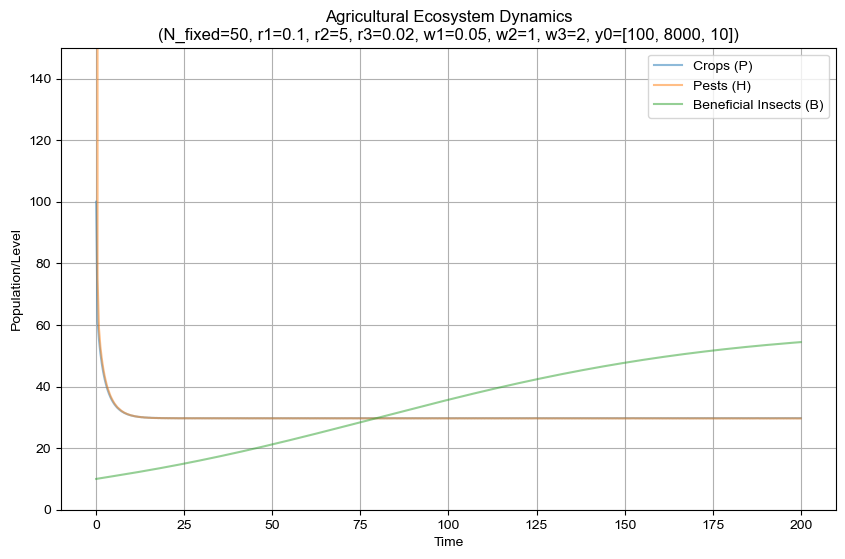

-4005000.0
0.03
-3874221.614277346
0.03000002322139668
-1772727.0959462253
0.030000464427933558
-2026020.7094153247
0.03000069649724775
-4353502.943815745
-25.295574498649284
-75315696.8196686
-88.06621121454846
-162028965.75504085
0.03000232486620823
-1415998.6672729654
0.030002323308199463
-3398892.033470221
0.030000110756343235
-3210803.1880486426
0.030000166128772217
-2183728.6616527257
0.030000442997257133
-1796520.3098733607
0.03000049223638833
-1673794.2828043583
0.030000553758507482
-2055855.1628100693
0.030000553723389455
-1826442.7811833431
0.030000664456087185
-1744250.762525711
0.03000071981665265
-1330828.797702508
0.030000996622129922
-1217587.6277504053
0.030001045842976446
-1156501.819061856
0.030001107348962375
-1238412.3552664677
0.030001107326333914
-989509.9349309017
0.030001366623508142
-926719.4931065977
0.030001496237655512
-521436.7286936414
0.030002144376137966
-315180.3662141678
0.030002259775440854
-283480.1749696975
0.03000240383818331
-529223.4411732275
0.0

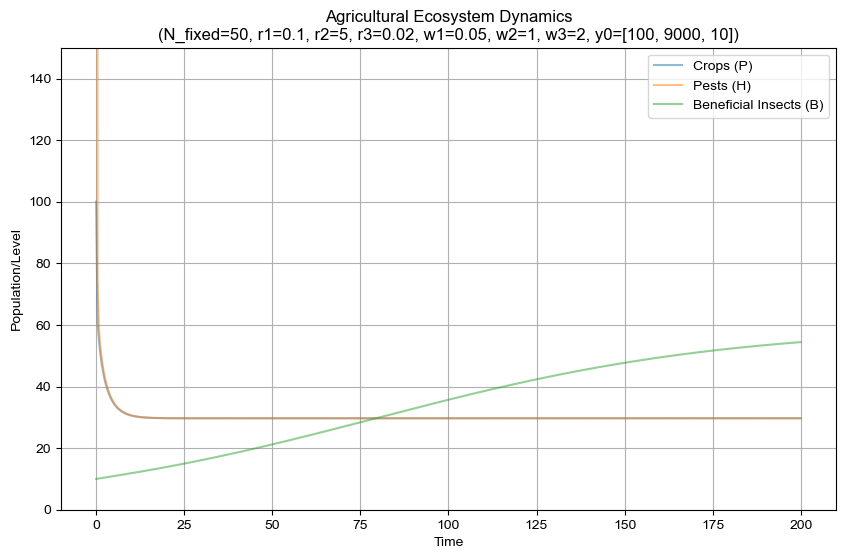

-4999950000000.0
0.03
-4837433678546.558
0.030000000020680897
-2223852743078.229
0.03000000041361796
-2532810318999.306
0.030000000620426827
-5202320666816.841
-27823.864931396398
-91386405248307.95
-97623.4426954056
-183047588749003.34
0.03000000206809197
-8128628785730.96
0.03000000206809074
-4185219478606.07
0.03000000010702045
-3943549003252.2017
0.030000000160530678
-2580433640439.9175
0.030000000428081788
-2021889538932.2678
0.03000000047564645
-1870956402057.3333
0.03000000053510225
-2454070566067.077
0.030000000535102215
-2164932855294.028
0.030000000642122642
-2063521696317.26
0.030000000695632852
-1548543913468.9497
0.030000000963183907
-1400200884490.497
0.030000001010748553
-1326325975209.2983
0.030000001070204337
-1440716781318.7603
0.03000000107020431
-1153570852432.2341
0.030000001308024542
-1080540300084.3279
0.03000000142693463
-612809931944.6329
0.030000002021485117
-376762376024.5288
0.03000000212718313
-339404382868.9854
0.030000002259305485
-619174763928.2256
0.030

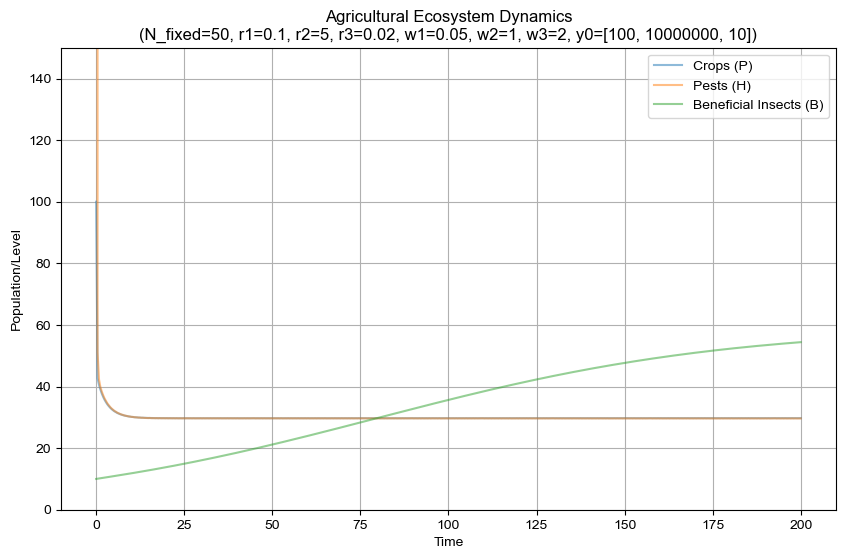

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib

# Solve the issue of negative signs in axis labels
matplotlib.rcParams['axes.unicode_minus'] = False
# Set font family
plt.rcParams['font.family'] = ['Arial']

# -----------------------------
# 1. Define the differential equations
# -----------------------------
# Differential equations for the agricultural ecosystem
def agricultural_ecosystem(t, y, params):
    P, H, B = y  # N is now a fixed parameter
    N = params['N_fixed']  # Use a fixed value for N

    # Crop dynamics
    dPdt = (params['r1'] * (N - params['w1'] * H * P) 
            - params['G'] * P 
            - params['mu_P'] * P)
    
    # Pest dynamics
    if H > 5 * B:  # Condition: H is more than 5 times B
        pest_reduction = params['beta_linear'] * B  # Linear dependence on B
    else:
        pest_reduction = params['beta_interaction'] * B * H  # Interaction dependence

    dHdt = (params['r2'] * H * (1 - H / (params['w2'] * P)) 
            - pest_reduction)  # Apply the dynamically chosen reduction term
    print(params['r2'] * H * (1 - H / (params['w2'] * P)))
    print(pest_reduction)
    
    # Beneficial insect dynamics
    dBdt = (params['r3'] * B * (1 - B / (params['w3'] * H)))
    
    return [dPdt, dHdt, dBdt]

# -----------------------------
# 2. Define parameters
# -----------------------------
params = {
    'r1': 0.1,       # Growth rate of crops
    'r2': 5,       # Growth rate of pests
    'r3': 0.02,      # Growth rate of beneficial insects
    'w1': 0.05,      # Interaction coefficient between pests and crops
    'w2': 1,         # Interaction coefficient between crops and pests
    'w3': 2,         # Interaction coefficient between pests and beneficial insects
    'beta_linear': 0.003,
    'beta_interaction': 0.0003,  # Impact of beneficial insects on pests
    'G': 0.01,       # Seasonal harvesting rate
    'mu_P': 0.01,    # Natural mortality rate of crops
    'mu_H': 0.02,    # Natural mortality rate of pests
    'mu_B': 0.01,    # Natural mortality rate of beneficial insects
    'N_fixed': 50    # Fixed value for nutrients
}

# -----------------------------
# 3. Define time settings
# -----------------------------
t_span = (0, 200)  # Time span for simulation
t_eval = np.linspace(t_span[0], t_span[1], 500)  # Time points for evaluation

# -----------------------------
# 4. Simulate the system for varying pest initial values
# -----------------------------
pest_initial_values = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000000]

# Loop through different initial pest values and plot results
for H_init in pest_initial_values:
    y0 = [100, H_init, 10]  # Initial values for P, H, B
    
    # Solve the system of differential equations
    solution = solve_ivp(
        agricultural_ecosystem,
        t_span,
        y0,
        args=(params,),
        t_eval=t_eval,
        method='RK45',
        dense_output=True  # Enable dense output for interpolation
    )
    
    # Extract the results
    P, H, B = solution.sol(t_eval)

    # -----------------------------
    # 5. Plotting
    # -----------------------------
    # Generate a formatted string for the parameters
    init_params = (
        f"N_fixed={params['N_fixed']}, "
        f"r1={params['r1']}, r2={params['r2']}, r3={params['r3']}, "
        f"w1={params['w1']}, w2={params['w2']}, w3={params['w3']}, "
        f"y0={[100, H_init, 10]}"
    )
    
    plt.figure(figsize=(10, 6))
    plt.plot(t_eval, P, label='Crops (P)', alpha=0.5)
    plt.plot(t_eval, H, label='Pests (H)', alpha=0.5)
    plt.plot(t_eval, B, label='Beneficial Insects (B)', alpha=0.5)
    plt.ylim(0, 150)  # Set y-axis limits for consistency
    
    plt.xlabel('Time')
    plt.ylabel('Population/Level')
    plt.title(f"Agricultural Ecosystem Dynamics\n({init_params})")  # Add params to the title
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()


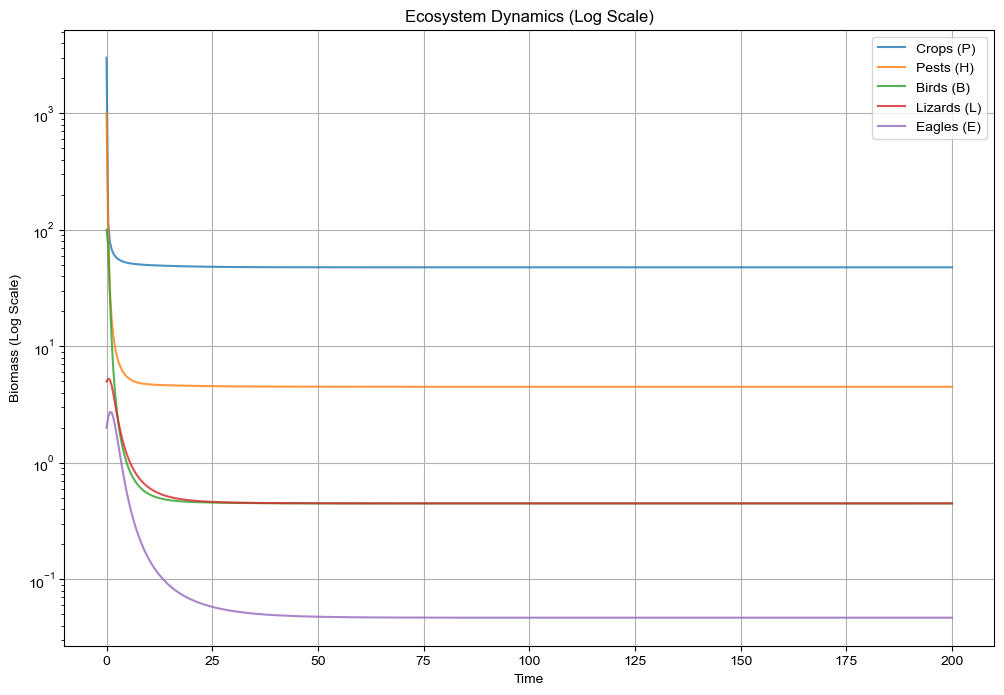

In [163]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Differential equations for the ecosystem dynamics
def ecosystem_dynamics(t, y, params):
    P, H, B, L, E = y  # Unpack state variables

    # Unpack parameters
    r1, r2, r3, r4, r5 = params['r1'], params['r2'], params['r3'], params['r4'], params['r5']
    w1, w2, w3, w4, w5, w6 = params['w1'], params['w2'], params['w3'], params['w4'], params['w5'], params['w6']
    G, C = params['G'], params['C']
    K_H, K_B, K_L, K_E = params['K_H'], params['K_B'], params['K_L'], params['K_E']

    
    
    # Equations
    dPdt = r1 * P - w1 * H * P - G * P
    dHdt = r2 * H * (1 - H / (params['e_f'] * P)) - w2 * B * H - w3 * L * H - C * H
    dBdt = r3 * B * (1 - B / (params['e_f'] * H)) - w4 * E * B
    dLdt = r4 * L * (1 - L / (params['e_f'] * H)) - w5 * E * L
    dEdt = r5 * E * (1 - E / (params['e_f']/2 * (L + B))) + w6 * (E * B + E * L)

    return [dPdt, dHdt, dBdt, dLdt, dEdt]

# Parameters
params = {
    'r1': 0.1,  # Growth rate of crops
    'r2': 0.5,  # Growth rate of pests
    'r3': 0.3,  # Growth rate of birds
    'r4': 0.2,  # Growth rate of lizards
    'r5': 0.1,  # Growth rate of eagles
    'w1': 0.02, 'w2': 0.01, 'w3': 0.03, 'w4': 0.02, 'w5': 0.01, 'w6': 0.005,  # Interaction coefficients
    'e_f': 0.1, # Energy flow from upper level to lower level
    'G': 0.01,  # Harvesting rate of crops
    'C': 0.01,  # Control rate of pests
    'K_H': 100, 'K_B': 50, 'K_L': 30, 'K_E': 5,  # Carrying capacities
}

# Initial conditions
P0, H0, B0, L0, E0 = 3000, 1000, 100, 5, 2  # Initial populations
y0 = [P0, H0, B0, L0, E0]

# Time span for simulation
t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Solve the system of differential equations
solution = solve_ivp(
    ecosystem_dynamics, t_span, y0, args=(params,), t_eval=t_eval, method='RK45'
)

# Extract solution
P, H, B, L, E = solution.y

# Plot results
plt.figure(figsize=(12, 8))
plt.plot(t_eval, P, label='Crops (P)', alpha=0.8)
plt.plot(t_eval, H, label='Pests (H)', alpha=0.8)
plt.plot(t_eval, B, label='Birds (B)', alpha=0.8)
plt.plot(t_eval, L, label='Lizards (L)', alpha=0.8)
plt.plot(t_eval, E, label='Eagles (E)', alpha=0.8)

plt.yscale('log')  # Set the y-axis to logarithmic scale
plt.xlabel('Time')
plt.ylabel('Biomass (Log Scale)')
plt.title('Ecosystem Dynamics (Log Scale)')
plt.legend()
plt.grid()
plt.show()

In [207]:
# weights 可以根据

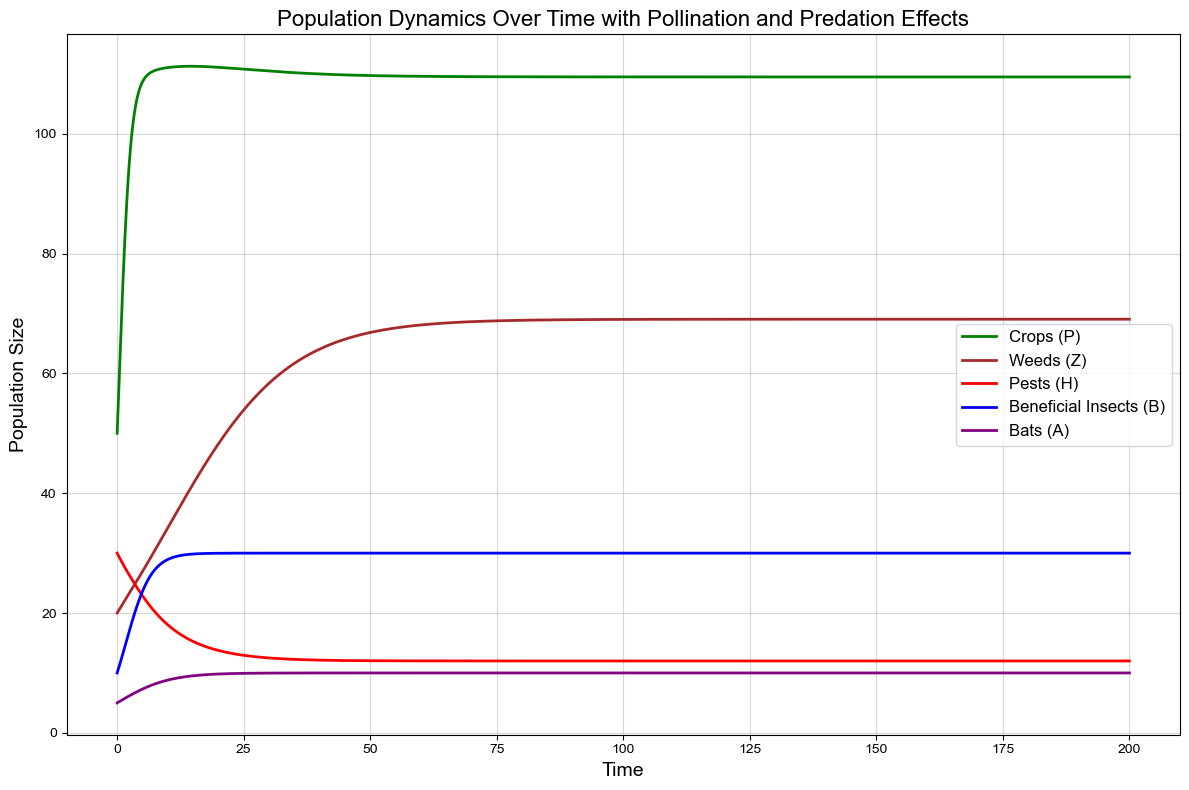

NameError: name 'ax' is not defined

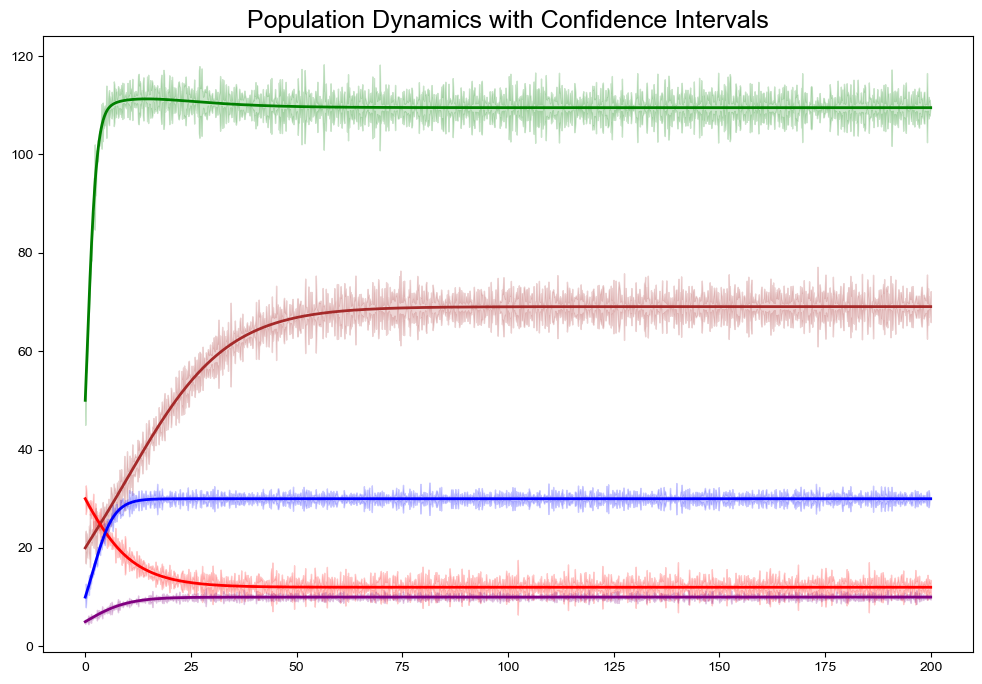

In [221]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the ODE system
def ecosystem(y, t, params):
    P, Z, H, B, A = y  # P: crops, Z: weeds, H: pests, B: beneficial insects, A: bats
    r_p, K_P, gamma, w, C_p, delta_p, k, r_z, K_Z, alpha, r_h, K_H, beta, delta_h, r_b, K_B, r_a, K_A, delta_a, mu_a = params
    
    # ODEs
    dPdt = ((r_p + (delta_p * A) / (1 + k * A)) / (1 + C_p)) * P * (1 - (P + gamma * Z + w * H) / K_P)
    dZdt = r_z * Z * (1 - (Z + alpha * P) / K_Z)
    dHdt = r_h * H * (1 - (H + beta * B) / K_H) - C_p * H - delta_h * A * H
    dBdt = r_b * B * (1 - B / K_B)
    dAdt = r_a * A * (1 - A / K_A) - mu_a * A
    return [dPdt, dZdt, dHdt, dBdt, dAdt]

params = [
    0.6,    # r_p: crop growth rate (increased further to favor crops)
    120,    # K_P: crop carrying capacity (increased for crops)
    0.1,    # gamma: weeds competition coefficient (further reduced)
    0.3,    # w: pests effect on crops
    0.1,    # C_p: pesticide concentration
    0.1,    # delta_p: pollination efficiency by bats
    0.05,   # k: saturation constant for pollination
    0.1,    # r_z: weeds growth rate (reduced further)
    80,     # K_Z: weeds carrying capacity (reduced for weeds)
    0.1,    # alpha: crop competition effect on weeds
    0.5,    # r_h: pests growth rate
    45,     # K_H: pests carrying capacity
    0.2,    # beta: beneficial insects effect on pests
    0.02,   # delta_h: bats predation on pests
    0.4,    # r_b: beneficial insects growth rate
    30,     # K_B: beneficial insects carrying capacity
    0.5,    # r_a: bats growth rate (further reduced to limit bats)
25,     # K_A: bats carrying capacity (reduced further to cap bats below crops)
    0.5,   # delta_a: crops support for bats
    0.3     # mu_a: bats natural death rate (increased to further limit bats)
]

# Initial conditions
P0 = 50    # initial crop population
Z0 = 20    # initial weed population
H0 = 30    # initial pest population
B0 = 10    # initial beneficial insect population
A0 = 5     # initial bat population
y0 = [P0, Z0, H0, B0, A0]

# Time span
t = np.linspace(0, 200, 1600)  # from 0 to 200 time units

# Solve ODEs
solution = odeint(ecosystem, y0, t, args=(params,))
P, Z, H, B, A = solution.T

# Plot results
plt.figure(figsize=(12, 8))

# Crops
plt.plot(t, P, label='Crops (P)', color='green', linewidth=2)
# Weeds
plt.plot(t, Z, label='Weeds (Z)', color='brown', linewidth=2)
# Pests
plt.plot(t, H, label='Pests (H)', color='red', linewidth=2)
# Beneficial Insects
plt.plot(t, B, label='Beneficial Insects (B)', color='blue', linewidth=2)
# Bats
plt.plot(t, A, label='Bats (A)', color='purple', linewidth=2)

# Fancy customization
plt.title('Population Dynamics Over Time with Pollination and Predation Effects', fontsize=16)
plt.legend(fontsize=12, loc='upper right', bbox_to_anchor=(1.05, 1))  # 图例靠右上角

plt.xlabel('Time', fontsize=14)
plt.ylabel('Population Size', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.tight_layout()

plt.show()

# Define a function to simulate variability (e.g., stochastic variations)
def add_variability(data, variability=0.1):
    noise = np.random.normal(0, variability, data.shape)
    upper = data + abs(noise)/2
    lower = data - abs(noise)/2
    return upper, lower

# Add variability to each population for confidence intervals
P_upper, P_lower = add_variability(P, variability=5)
Z_upper, Z_lower = add_variability(Z, variability=5)
H_upper, H_lower = add_variability(H, variability=3)
B_upper, B_lower = add_variability(B, variability=2)
A_upper, A_lower = add_variability(A, variability=1)

# Plot with confidence intervals
plt.figure(figsize=(12, 8))

# Crops
plt.plot(t, P, label='Crops (P)', color='green', linewidth=2)
plt.fill_between(t, P_lower, P_upper, color='green', alpha=0.2)

# Weeds
plt.plot(t, Z, label='Weeds (Z)', color='brown', linewidth=2)
plt.fill_between(t, Z_lower, Z_upper, color='brown', alpha=0.2)

# Pests
plt.plot(t, H, label='Pests (H)', color='red', linewidth=2)
plt.fill_between(t, H_lower, H_upper, color='red', alpha=0.2)

# Beneficial Insects
plt.plot(t, B, label='Beneficial Insects (B)', color='blue', linewidth=2)
plt.fill_between(t, B_lower, B_upper, color='blue', alpha=0.2)

# Bats
plt.plot(t, A, label='Bats (A)', color='purple', linewidth=2)
plt.fill_between(t, A_lower, A_upper, color='purple', alpha=0.2)

# Fancy customization
plt.title('Population Dynamics with Confidence Intervals', fontsize=18)
ax.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=12)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Population Size', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.tight_layout()

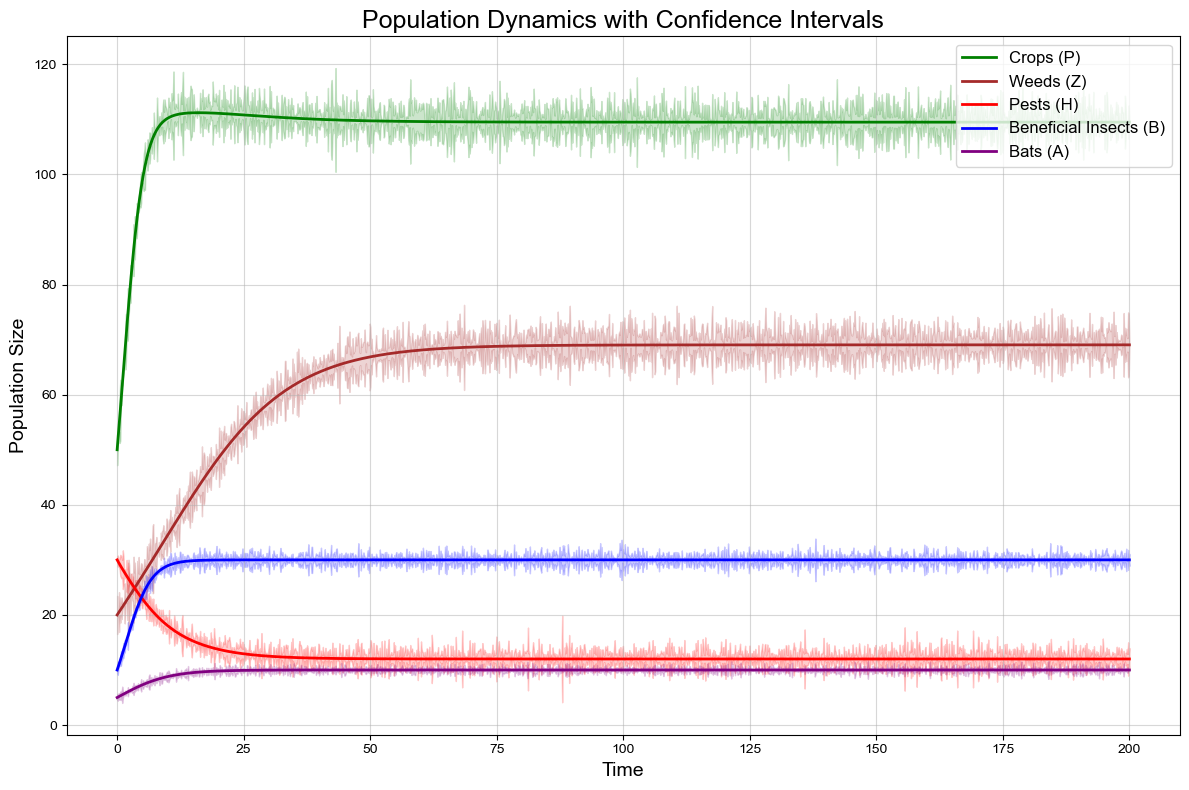

In [226]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the ODE system
def ecosystem(y, t, params):
    P, Z, H, B, A = y  # P: crops, Z: weeds, H: pests, B: beneficial insects, A: bats
    r_p, K_P, gamma, w, C_p, delta_p, k, r_z, K_Z, alpha, r_h, K_H, beta, delta_h, r_b, K_B, r_a, K_A, delta_a, mu_a = params
    
    # ODEs
    dPdt = ((r_p + (delta_p * A) / (1 + k * A)) / (1 + C_p)) * P * (1 - (P + gamma * Z + w * H) / K_P)
    dZdt = r_z * Z * (1 - (Z + alpha * P) / K_Z)
    dHdt = r_h * H * (1 - (H + beta * B) / K_H) - C_p * H - delta_h * A * H
    dBdt = r_b * B * (1 - B / K_B)
    dAdt = r_a * A * (1 - A / K_A) - mu_a * A
    return [dPdt, dZdt, dHdt, dBdt, dAdt]

# Parameters and initial conditions
params = [
    0.1, 120, 0.1, 0.3, 0.1, 0.1, 0.05, 0.1, 80, 0.1, 0.5, 45, 0.2, 0.02, 0.4, 30, 0.5, 25, 0.5, 0.3
]

P0, Z0, H0, B0, A0 = 50, 20, 30, 10, 5  # Initial populations
y0 = [P0, Z0, H0, B0, A0]

t = np.linspace(0, 200, 1600)  # Time span

# Solve ODEs
solution = odeint(ecosystem, y0, t, args=(params,))
P, Z, H, B, A = solution.T

# Define a function to simulate variability
def add_variability(data, variability=0.1):
    noise = np.random.normal(0, variability, data.shape)
    upper = data + abs(noise) / 2
    lower = data - abs(noise) / 2
    return upper, lower

# Add variability for confidence intervals
P_upper, P_lower = add_variability(P, variability=5)
Z_upper, Z_lower = add_variability(Z, variability=5)
H_upper, H_lower = add_variability(H, variability=3)
B_upper, B_lower = add_variability(B, variability=2)
A_upper, A_lower = add_variability(A, variability=1)

# Create subplots and plot
fig, ax = plt.subplots(figsize=(12, 8))

# Crops
ax.plot(t, P, label='Crops (P)', color='green', linewidth=2)
ax.fill_between(t, P_lower, P_upper, color='green', alpha=0.2)

# Weeds
ax.plot(t, Z, label='Weeds (Z)', color='brown', linewidth=2)
ax.fill_between(t, Z_lower, Z_upper, color='brown', alpha=0.2)

# Pests
ax.plot(t, H, label='Pests (H)', color='red', linewidth=2)
ax.fill_between(t, H_lower, H_upper, color='red', alpha=0.2)

# Beneficial Insects
ax.plot(t, B, label='Beneficial Insects (B)', color='blue', linewidth=2)
ax.fill_between(t, B_lower, B_upper, color='blue', alpha=0.2)

# Bats
ax.plot(t, A, label='Bats (A)', color='purple', linewidth=2)
ax.fill_between(t, A_lower, A_upper, color='purple', alpha=0.2)

# Customization
ax.set_title('Population Dynamics with Confidence Intervals', fontsize=18)
ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Population Size', fontsize=14)
ax.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=12)
ax.grid(alpha=0.5)

plt.tight_layout()
plt.show()


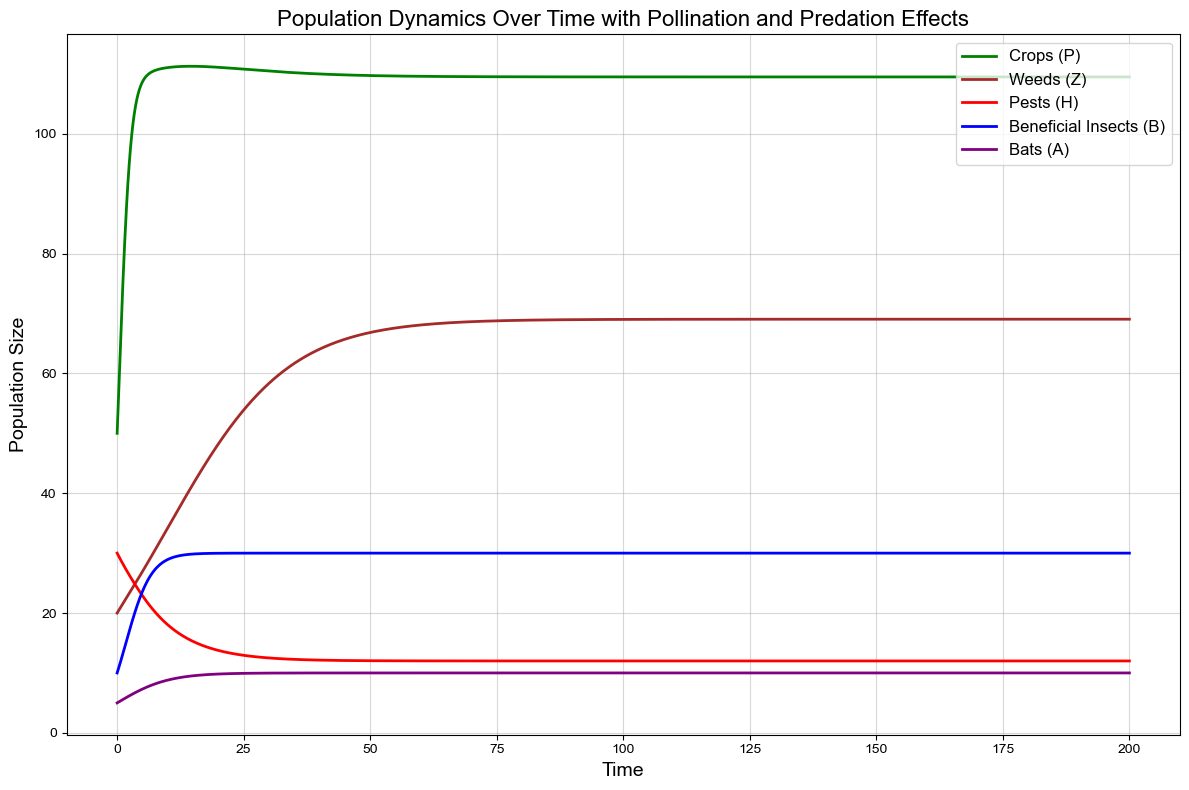

In [225]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the ODE system
def ecosystem(y, t, params):
    P, Z, H, B, A = y  # P: crops, Z: weeds, H: pests, B: beneficial insects, A: bats
    r_p, K_P, gamma, w, C_p, delta_p, k, r_z, K_Z, alpha, r_h, K_H, beta, delta_h, r_b, K_B, r_a, K_A, delta_a, mu_a = params
    
    # ODEs
    dPdt = ((r_p + (delta_p * A) / (1 + k * A)) / (1 + C_p)) * P * (1 - (P + gamma * Z + w * H) / K_P)
    dZdt = r_z * Z * (1 - (Z + alpha * P) / K_Z)
    dHdt = r_h * H * (1 - (H + beta * B) / K_H) - C_p * H - delta_h * A * H
    dBdt = r_b * B * (1 - B / K_B)
    dAdt = r_a * A * (1 - A / K_A) - mu_a * A
    return [dPdt, dZdt, dHdt, dBdt, dAdt]

# Parameters and initial conditions
params = [
    0.6, 120, 0.1, 0.3, 0.1, 0.1, 0.05, 0.1, 80, 0.1, 0.5, 45, 0.2, 0.02, 0.4, 30, 0.5, 25, 0.5, 0.3
]

P0, Z0, H0, B0, A0 = 50, 20, 30, 10, 5  # Initial populations
y0 = [P0, Z0, H0, B0, A0]

t = np.linspace(0, 200, 1600)  # Time span

# Solve ODEs
solution = odeint(ecosystem, y0, t, args=(params,))
P, Z, H, B, A = solution.T

# Plot results
plt.figure(figsize=(12, 8))

# Crops
plt.plot(t, P, label='Crops (P)', color='green', linewidth=2)
# Weeds
plt.plot(t, Z, label='Weeds (Z)', color='brown', linewidth=2)
# Pests
plt.plot(t, H, label='Pests (H)', color='red', linewidth=2)
# Beneficial Insects
plt.plot(t, B, label='Beneficial Insects (B)', color='blue', linewidth=2)
# Bats
plt.plot(t, A, label='Bats (A)', color='purple', linewidth=2)

# Fancy customization
plt.title('Population Dynamics Over Time with Pollination and Predation Effects', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Population Size', fontsize=14)
plt.legend(fontsize=12, loc='upper right', bbox_to_anchor=(1, 1))  # 图例固定在右上角
plt.grid(alpha=0.5)
plt.tight_layout()

plt.show()
